# Model for Simulating Energy and Economic Performance of Power Stations in DR Aggregations V5.0

Includes variables for control type and if the PV system is plug-in or not.

To do:
* make sure plug-in version baseline isn't being negated on non-event days!
* discharge maximum

## Structure of the notebook

1) globals define
2) hardware and system characteristics define from data sets
3) energy modeling
   * PV modeling
   * battery modeling
4) financial modeling
5) DR performance modeling
6) big loop
7) basic results analysis


In [154]:
import pandas as pd
import numpy as np
import requests
import pvlib
import matplotlib.pyplot as plt  # for visualization
import math
from datetime import datetime
from statistics import median
from statistics import mean
from keys import *
from typing import List, Dict, Any
from collections import deque
import glob

In [252]:
#GLOBALS
#note that these coordinates are the inputs for the NREL API,
#the coordinates used by the NREL API for the weather file are slightly different
#see below
lat = 40.7128
long = -74.0060

#optimize for summer when DR program is in effect
#also minimizes shading from buildings during PSH
tilt = lat #math.floor(lat - 15)
print("tilt: " + str(tilt))

#default to south facing
azimuth = 180

#14% losses
shading = .86

#max 99% efficient mppt battery charger - used for PV to battery
mppt = .99

# conversion rate when charging battery from grid - used for grid to battery
acToDC = .9

# microinverter conversion efficiency is 95% - used for PV to grid
miEff = 0.95

# max 80% depth of discharge for LiFePO4 batteries under normal circumstances
# & 95% to maximize flexibiltiy during events
LiFePOdod = 0.80
LiFePOdod_event = 0.95

#Max Hardware Sizes
pvMaxW = 1200

#PV degredation rate is assumed to be 1% annually
DEG_RATE = 0.01

#days in the months May - September
daysInMonth = [31,30,31,31,30]
drSeasonStartDay = 121

# self consumption of both controller and power station
controllerSC = 1 #Raspberry Pi Zero 2W controller self-consumption
powerStationSC = 8.62 #power station no-load self-consumption with AC outputs turned on
scWDC = controllerSC + powerStationSC
dailySelfConsumptionWhDC = scWDC * 24
#annualSelfConsumptionkWhDC = scWDC * 24 * 365 * 0.001


tilt: 40.7128


## Commercially Available Power Station Data


In [253]:
hardware_df = pd.read_csv('data/PowerStations_LiFePo4_June29_2026.csv')

#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Min PV Voltage','Max PV Voltage','Warranty Years','Lifespan','Notes','Estimated Full Charge Time','Estimated Minimum Grid Charge Efficiency'])

retailPriceColumns = ['Retail Price (3/14/2026)']

#filter out batteries over specified size
#print(hardware_df[hardware_df['Battery Wh'] > 2000])
#hardware_df = hardware_df[hardware_df['Battery Wh'] <= 2000]



In [254]:
pC = []
for c in hardware_df.columns:
    if 'Price (' in c:
        pC.append(c)

#get average retail prices
hardware_df['retail price']= hardware_df[retailPriceColumns].mean(axis=1)
hardware_df = hardware_df.drop(columns=pC) #drop raw price data

hardware_df = hardware_df.dropna(subset=['retail price']) #drop rows with missing avg prices

hardware_df.head()

,Make,Model,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,Passthrough,community API,official API,potential API,retail price
0,Jackery,Explorer 300 Plus,288.00,100,5.0,300.0,100.0,2.00,NaN,85.0,3000,80,True,True,False,False,299.0
1,Jackery,Explorer 600 Plus,632.00,200,10.5,800.0,1800.0,1.60,NaN,85.0,4000,70,True,True,False,False,429.0
2,Jackery,Explorer 700 Plus,680.96,600,11.0,1000.0,NaN,1.75,NaN,85.0,4000,70,NaN,True,False,False,599.0
3,Jackery,Explorer 1000 Plus,1264.64,800,22.0,2000.0,NaN,1.70,NaN,85.0,4000,70,NaN,True,False,False,599.0
4,Jackery,Explorer 2000 Plus,2042.80,1400,24.0,3000.0,NaN,2.00,NaN,85.0,4000,70,NaN,True,False,False,1099.0


In [255]:
hardware_df = hardware_df[(hardware_df['official API']==True)| (hardware_df['community API']==True)]

In [256]:
# #display(hardware_df.tail())

# #get average charge time percent for 80% relative to a 100% charge
# hardware_df['charge ratio']= hardware_df['80 Per Grid Charge Hours']/hardware_df['Full Grid Charge Hours']

# #display(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'])
# #get the average ratio of 80% to 100% 
# eightyCT = round(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'].mean()*100,2)*.01
# print(str(eightyCT*100) + '% of the full charge time is spent charging from 0-80%.')
# # #display(hardware_df.tail())

# #update full charge column
# hardware_df['Full Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] = hardware_df['80 Per Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] / eightyCT

# #update 80% charge column
# hardware_df['80 Per Grid Charge Hours'].loc[hardware_df['80 Per Grid Charge Hours'].isnull()] = hardware_df['Full Grid Charge Hours'].loc[hardware_df['80 Per Grid Charge Hours'].isnull()] * eightyCT

#display(hardware_df.tail())
#get average charge time percent for 80% relative to a 100% charge
hardware_df['charge ratio'] = hardware_df['80 Per Grid Charge Hours'] / hardware_df['Full Grid Charge Hours']
#display(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'])
#get the average ratio of 80% to 100%
eightyCT = round(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'].mean() * 100, 2) * .01
print(str(eightyCT * 100) + '% of the full charge time is spent charging from 0-80%.')

# #display(hardware_df.tail())
#update full charge column
full_missing = hardware_df['Full Grid Charge Hours'].isnull()
hardware_df.loc[full_missing, 'Full Grid Charge Hours'] = (
    hardware_df.loc[full_missing, '80 Per Grid Charge Hours'] / eightyCT
)

#update 80% charge column
eighty_missing = hardware_df['80 Per Grid Charge Hours'].isnull()
hardware_df.loc[eighty_missing, '80 Per Grid Charge Hours'] = (
    hardware_df.loc[eighty_missing, 'Full Grid Charge Hours'] * eightyCT
)

63.99% of the full charge time is spent charging from 0-80%.


In [257]:
tP = hardware_df.shape[0]

inverterEfficiencyMean = round(hardware_df['Inverter Efficiency'].mean(),4)
invEffDefault = inverterEfficiencyMean * 0.01
print('Default Efficiency for use in model: ' + str(inverterEfficiencyMean))
print('% with unknown efficiency: ' + str(100*hardware_df[hardware_df['Inverter Efficiency'].isnull()].shape[0]/tP))
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency'].fillna(inverterEfficiencyMean)
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency']*.01


Default Efficiency for use in model: 86.6667
% with unknown efficiency: 0.0


In [258]:
# price per Wh
hardware_df['$/Wh'] = hardware_df['retail price']/hardware_df['Battery Wh']

In [259]:
hardware_df.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 0 to 53
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      45 non-null     str    
 1   Model                     45 non-null     str    
 2   Battery Wh                45 non-null     float64
 3   Max PV Watts              45 non-null     int64  
 4   Max PV Amps               29 non-null     float64
 5   Inverter Watts            44 non-null     float64
 6   Max AC Input Watts        37 non-null     float64
 7   Full Grid Charge Hours    45 non-null     float64
 8   80 Per Grid Charge Hours  45 non-null     float64
 9   Inverter Efficiency       45 non-null     float64
 10  Cycles                    45 non-null     int64  
 11  DoD                       45 non-null     int64  
 12  Passthrough               2 non-null      object 
 13  community API             45 non-null     bool   
 14  official API              45

In [260]:
hardware_df.describe()

,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,retail price,charge ratio,$/Wh
count,45.000000,45.000000,29.000000,44.000000,37.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,4.000000,45.000000
mean,1165.564444,610.666667,13.610345,1475.000000,1128.324324,1.581524,1.011585,0.866667,3511.111111,78.888889,562.800000,0.639881,0.576610
std,751.915725,479.779305,6.417017,864.580823,659.223873,0.696704,0.446749,0.035355,678.307460,3.178209,305.745408,0.103954,0.257100
min,204.000000,100.000000,5.000000,300.000000,100.000000,0.820441,0.525000,0.800000,2500.000000,70.000000,149.000000,0.500000,0.305339
25%,512.000000,200.000000,8.200000,600.000000,500.000000,1.170000,0.750000,0.850000,3000.000000,80.000000,300.000000,0.607143,0.389757
50%,1024.000000,500.000000,12.000000,1500.000000,1200.000000,1.500000,0.959850,0.850000,3500.000000,80.000000,549.000000,0.654762,0.493490
75%,2000.000000,1000.000000,20.000000,2200.000000,1800.000000,1.800000,1.151820,0.900000,4000.000000,80.000000,799.000000,0.687500,0.682617
max,3072.000000,2400.000000,25.000000,3600.000000,2400.000000,4.500000,2.879550,0.900000,6000.000000,80.000000,1499.000000,0.750000,1.486352


In [261]:
# data snapshot
print('Total Number of Companies: ' + str(hardware_df.drop_duplicates(subset=['Make']).shape[0]))
print('Total Number of Products: ' + str(tP))

print('')
print('*** PV Charge Time (without losses) ***')
print('Min:' + str(min(hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99))))
print('Max:' + str(max(hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99))))
pvChargeMed = (hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99)).median()
print('Median:' + str(pvChargeMed))

Total Number of Companies: 6
Total Number of Products: 45

*** PV Charge Time (without losses) ***
Min:0.8619528619528619
Max:5.818181818181818
Median:2.0686868686868687


In [262]:
hardware_df.iloc[28]

Make                            EcoFlow
Model                       DELTA 2 Max
Battery Wh                       2048.0
Max PV Watts                       1000
Max PV Amps                        15.0
Inverter Watts                   2400.0
Max AC Input Watts               1800.0
Full Grid Charge Hours         1.719019
80 Per Grid Charge Hours            1.1
Inverter Efficiency                 0.9
Cycles                             3000
DoD                                  80
Passthrough                         NaN
community API                     False
official API                       True
potential API                     False
retail price                     1499.0
charge ratio                        NaN
$/Wh                           0.731934
Name: 30, dtype: object

In [263]:
def get_round_trip_efficiency(battery_index, acToDC=acToDC):
    """Round-trip efficiency (grid -> battery -> load) for one battery in
    hardware_df: charge-side loss (acToDC, same for every battery) times
    that battery's own discharge-side inverter efficiency. No separate
    battery-chemistry loss is modeled here -- conversion losses are the
    only losses this model accounts for."""
    row = hardware_df.loc[battery_index]
    inverter_eff = row['Inverter Efficiency']  # already converted to a 0-1 fraction in cell 8
    round_trip_eff = acToDC * inverter_eff

    print(f"Battery index {battery_index}:")
    print(f"  Charge efficiency (acToDC):     {acToDC:.4f}")
    print(f"  Discharge efficiency (inverter): {inverter_eff:.4f}")
    print(f"  Round-trip efficiency:           {round_trip_eff:.4f} ({round_trip_eff*100:.1f}%)")

    return round_trip_eff

# example
rt_eff = get_round_trip_efficiency(28)

Battery index 28:
  Charge efficiency (acToDC):     0.9000
  Discharge efficiency (inverter): 0.9000
  Round-trip efficiency:           0.8100 (81.0%)


## Con Ed Network Data

In [166]:
# read in hardware data to dataframe
networks_df = pd.read_csv('data/conEdNetworks2026.csv')

networksToSim = ['bowling green','borden','sunnyside','grasslands','fresh kills','central bronx','fordham','park slope']
networks_df[networks_df['network'].isin(networksToSim)]

,borough,network,start time,end time,tier
0,bronx,central bronx,19:00,23:00,2
1,bronx,fordham,16:00,20:00,2
12,brooklyn,park slope,14:00,18:00,2
19,manhattan,bowling green,11:00,15:00,1
56,queens,borden,14:00,18:00,1
64,queens,sunnyside,16:00,20:00,1
66,staten island,fresh kills,19:00,23:00,1
74,westchester,grasslands,16:00,20:00,1


In [167]:
#returns the network info for a given network
#args: network name
def getNetworkInfo(networkName):
    return networks_df.loc[networks_df['network']== networkName]

#returns the tier for a given item in the network info list
#args: network name
def getDLRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['tier'].iloc[0]
    #tier 2 networks pay at a higher rate
    if t == 1:
        return 18
    else:
        return 25
    
#returns the borough for a given item in the network info list
#args: network name
def getCSRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['borough'].iloc[0]
    #westchester and staten island pay at a lower rate
    if t not in ['westchester','staten island']:
        return 18
    else:
        return 6

#args: network name
def getTotalRate(networkName):
    return getDLRPrate(networkName) + getCSRPrate(networkName)
    
#returns borough name
#args: network name
def getBorough(networkName):
    n = getNetworkInfo(networkName)
    return n['borough'].iloc[0]

#returns event start time
#args: network name
def getStartTime(networkName):
    n = getNetworkInfo(networkName)
    return int(n['start time'].iloc[0].split(":")[0])

In [168]:
# # Load the real ResStock fridge draw (average across the unique NYC
# # multifamily buildings), replacing the fixed loadTwoW watt value.
# # loadOneW (AC) and loadOneW_Replacement (fan) stay fixed for now.

# fridge_path = max(glob.glob("data/ResStock_fridge_hourly_W_with_average_*.csv"))
# print("Using fridge file:", fridge_path)

# fridge_df = pd.read_csv(fridge_path, index_col=0, parse_dates=True)
# fridge_hourly_W = fridge_df["average"].to_numpy()

# n_hours_model = len(hourly_array_power_yield_test)  # match whichever variable your loop actually uses
# assert len(fridge_hourly_W) == n_hours_model, (
#     f"fridge array length ({len(fridge_hourly_W)}) != model hours ({n_hours_model})"
# )

# loads = {
#     'loadOneW': 1000,              # AC — still fixed, unchanged for now
#     'loadTwoW': fridge_hourly_W,   # fridge — avg ResStock hourly profile
#     'loadOneW_Replacement': 75,    # fan — still fixed, unchanged for now
# }

# print(f"Fridge array: {fridge_df.shape[1] - 1} buildings averaged, "
#       f"annual mean {fridge_hourly_W.mean():.1f} W, peak {fridge_hourly_W.max():.1f} W")

## PV Performance Modeling

In [169]:
#get TMY via API
try:
    df_tmy, metadata = pvlib.iotools.get_nsrdb_psm4_tmy(
        latitude=lat,
        longitude=long,
        api_key=NREL_API_KEY,
        time_step=60,
        email='nathaa@rpi.edu',  # <-- any email works here fine
        year='tmy-2024')
except requests.HTTPError as e:
    print("Status code:", e.response.status_code)
    print("Raw response text:")
    print(e.response.text)
    raise

metadata

{'Source': 'NSRDB',
 'Location ID': '1243965',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Time Zone': -5,
 'Local Time Zone': -5,
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing I

In [170]:
df_tmy.to_csv("data/tmy_2024_NYC.csv", index=True)

In [171]:
# make a Location object corresponding to this TMY
location = pvlib.location.Location(name='NYC',
                                   latitude=metadata['latitude'],
                                   longitude=metadata['longitude'])

location

Location: 
  name: NYC
  latitude: 40.73
  longitude: -74.02
  altitude: -2.0
  tz: UTC

In [172]:
#normalize all years to 2020
#remove timezone info #,tzinfo=None
df_tmy.index = df_tmy.index.map(lambda t: t.replace(year=2020))

#uncomment the 30 minute shifts if using data that is right-labeled at hourly intervals!
# Note: TMY datasets are right-labeled hourly intervals, e.g. the
# 10AM to 11AM interval is labeled 11.  We should calculate solar position in
# the middle of the interval (10:30), so we subtract 30 minutes:
times = df_tmy.index #- pd.Timedelta('30min')
solar_position = location.get_solarposition(times)
# but remember to shift the index back to line up with the TMY data:
#solar_position.index += pd.Timedelta('30min')

solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2020-01-01 00:30:00-05:00,161.167644,161.167644,-71.167644,-71.167644,22.397593,-3.190860
2020-01-01 01:30:00-05:00,154.001161,154.001161,-64.001161,-64.001161,54.029306,-3.210673
2020-01-01 02:30:00-05:00,143.834623,143.834623,-53.834623,-53.834623,72.365773,-3.230477
2020-01-01 03:30:00-05:00,132.705852,132.705852,-42.705852,-42.705852,84.714658,-3.250272
2020-01-01 04:30:00-05:00,121.355180,121.355180,-31.355180,-31.355180,94.580427,-3.270057
...,...,...,...,...,...,...
2020-12-31 19:30:00-05:00,121.549755,121.549755,-31.549755,-31.549755,265.621718,-3.441097
2020-12-31 20:30:00-05:00,132.896245,132.896245,-42.896245,-42.896245,275.528481,-3.460697
2020-12-31 21:30:00-05:00,144.009842,144.009842,-54.009842,-54.009842,287.965009,-3.480288
2020-12-31 22:30:00-05:00,154.134861,154.134861,-64.134861,-64.134861,306.489310,-3.499870


In [173]:
#get monthly temperature averages for validation
# for m in range(12):
#     df_tmy['Temperature']

In [174]:
# temperature coef
gamma_pdc = -0.003  # divide by 100 to go from %/°C to 1/°C

all_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']
parameters = all_parameters['open_rack_glass_polymer']

#args: tilt, azimuth
def getPOA(t,a):
    #fixed tilt POA
    df_poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=t,
        surface_azimuth=a,
        dni=df_tmy['dni'],
        ghi=df_tmy['ghi'],
        dhi=df_tmy['dhi'],
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        model='isotropic')

    #print(df_poa.keys())
    return df_poa

#DC power going in to battery after accounting for shading and equipment derating
#https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.pvsystem.pvwatts_dc.html#
#args: power, temp coefficient, array nameplate watts
def getPowerYield(p,g,n):
    
    # note the "splat" operator "**" which expands the dictionary "parameters"
    # into a comma separated list of keyword arguments
    cell_temperature = pvlib.temperature.sapm_cell(
        p['poa_global'], df_tmy['temp_air'], df_tmy['wind_speed'], **parameters)
    
    array_power = pd.DataFrame({
        'power': pvlib.pvsystem.pvwatts_dc(p['poa_global'], cell_temperature, n, g,temp_ref=25.0)
    })

    #yieldDC is actual power going in to battery after losses
    array_power['yieldDC'] = array_power['power'] * shading * mppt

    #yieldAC is actual power going in to grid after losses
    array_power['yieldAC'] = array_power['power'] * shading * miEff
    
    return array_power
    #array_power = pvlib.pvsystem.pvwatts_dc(df_poa['poa_global'], cell_temperature, n, g,temp_ref=25.0)

    #factor in 14% shading losses + 1% mppt losses
    #return array_power * shading * mppt

# #convert DC to AC with PV Watts model
# #https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.inverter.pvwatts.html#pvlib.inverter.pvwatts
# #args: dc power input to inverter, inverter nameplate max WAC output, nameplate efficiency


#returns the degraded power of the array for a given year
#args: PV watts, year, PV degradation rate
def getDegradedP(w,y,dR = DEG_RATE):
    d = 1 - dR
    return w*(d**y)

array_power_yield = getPowerYield(getPOA(tilt,azimuth),gamma_pdc, 100)
array_power_yield.head()

,power,yieldDC,yieldAC
2020-01-01 00:30:00-05:00,0.0,0.0,0.0
2020-01-01 01:30:00-05:00,0.0,0.0,0.0
2020-01-01 02:30:00-05:00,0.0,0.0,0.0
2020-01-01 03:30:00-05:00,0.0,0.0,0.0
2020-01-01 04:30:00-05:00,0.0,0.0,0.0


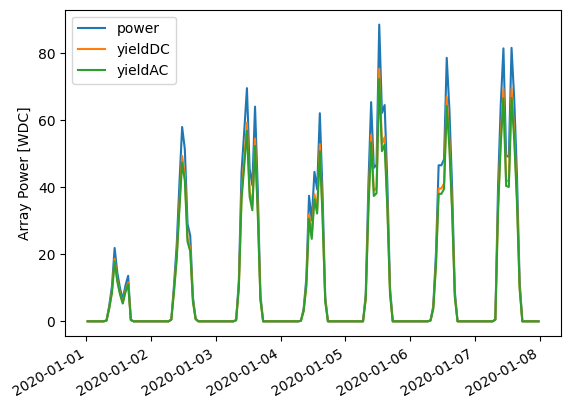

In [175]:
array_power_yield.head(24*7).plot()
plt.ylabel('Array Power [WDC]');

In [176]:
# this function gets yield data for a range of things
def getYieldData(tilt=tilt, gamma_pdc=gamma_pdc, maxPV=pvMaxW, pvInc=50, azimuths=(110, 180, 250)):
    """
    Get hourly and daily PV yields for all possible array sizes being modeled,
    at each of the given azimuths.

    Args:
        tilt (float): array tilt angle (degrees).
        gamma_pdc (float): PV temperature coefficient (1/°C).
        maxPV (int): max allowed PV nameplate wattage of any power station
                     in the database (default 1200).
        pvInc (int): increment (W) to step through array sizes (default 50).
        azimuths (iterable of int): azimuth angles to model (default (110, 180, 250)).

    Returns:
        dict: {
            '<azimuth>': {
                '<pW>': {
                    'hourly': <DataFrame from getPowerYield>,
                    'daily': {'dailyDC': [...], 'dailyAC': [...]}
                },
                ...
            },
            ...
        }
    """
    yieldData = {str(a): {} for a in azimuths}

    #print(f'Max PV: {maxPV}')

    for a in azimuths:
        poa = getPOA(tilt, a)

        aData = {}
        for pW in range(pvInc, maxPV + pvInc, pvInc):
            # get hourly power yields for a given array size (W)
            hY = getPowerYield(poa, gamma_pdc, pW)

            # get daily PV yields (Wh)
            # dYDC = []
            # dYAC = []
            # for d in range(365):
            #     dYDC.append(hY['yieldDC'].iloc[d*24:(d*24)+24].sum())
            #     dYAC.append(hY['yieldAC'].iloc[d*24:(d*24)+24].sum())
            dYDC = hY['yieldDC'].to_numpy().reshape(365, 24).sum(axis=1)
            dYAC = hY['yieldAC'].to_numpy().reshape(365, 24).sum(axis=1)

            aData[str(pW)] = {
                'hourly': hY,
                'daily': {'dailyDC': dYDC, 'dailyAC': dYAC}
            }

        yieldData[str(a)] = aData

    return yieldData
    

In [177]:
yieldData = getYieldData()

# Annual Energy Modeling

battery is only charged from the grid when an event is upcoming. This considers average solar in July

In [178]:
def pv_to_stored_charge(pv_w, plugin, acToDC):
    """Energy reaching the battery as stored charge, after conversion losses.
    plugin=True: pv_w is already AC (post-microinverter) -> battery charger (acToDC).
    plugin=False: pv_w is DC -> straight into battery, no conversion loss."""
    return pv_w * acToDC if plugin else pv_w

def battery_to_load(load_wac, iE):
    """AC load converted into the DC draw required from the battery
    (battery inverter, discharge side)."""
    return load_wac / iE

In [179]:
def simulate_hourly_energy(pvYieldW, batWh, loadWAC, iE, y: int = 0, plugin=True,
                            dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
                            LiFePOdod=LiFePOdod, acToDC=acToDC,
                            chargeTargetFraction=0.8,
                            drWindowStartHour=None,
                            maxChargeRateW=1800, maxDischargeRateW=None):
    """
    Step through a year hour-by-hour, simulating a charge/discharge cycle
    capped at once per calendar day, with any grid-sourced charging capped
    at maxChargeRateW (Wh/hour, AC-side) rather than applied instantly --
    the number of hours it takes depends on how large the gap is.

    loadWAC may be either a scalar (constant load every hour, the original
    behavior) or an array-like of length len(pvYieldW) giving an hourly
    load profile -- e.g. a load that's only "on" during certain months
    (see build_seasonal_load_array). Internally it's always expanded to a
    per-hour array so seasonal and constant loads are handled identically.

    OFF-GRID discharge triggers: either the battery reaches chargeTarget
    (80%) after 3pm on a day the cycle hasn't been used yet, OR projected
    overflow risk (reserving multi-hour headroom based on the trailing
    week's peak PV hour vs. load size) forces an early discharge to avoid
    curtailing PV, regardless of time or the daily cap. If discharge was
    triggered by overflow risk specifically, it reverts back to 'charging'
    as soon as that risk resolves (rather than waiting for the DoD floor),
    and frees the daily cycle back up so a normal 80%-target discharge can
    still happen later that day if conditions call for it.

    maxChargeRateW / maxDischargeRateW: AC-side hardware power caps
    (Wh/hour) that apply ONLY to grid-sourced battery charging and to
    battery discharge that serves the load -- NOT to PV-to-battery
    charging, which is left uncapped. This models something like a charger
    or inverter's rated AC power limit rather than the battery cell's own
    charge/discharge limit. Because they're AC-side, they're converted
    through acToDC / iE before being compared against the DC-side battery
    flows used internally:
      - charging: capped in DC terms as maxChargeRateW * acToDC, so the
        resulting AC grid draw (chargeAmount / acToDC) never exceeds
        maxChargeRateW. Defaults to 1800 (a typical charger AC power
        rating).
      - discharging: capped in DC terms as maxDischargeRateW / iE, so the
        resulting AC output to the load (servedWDC * iE) never exceeds
        maxDischargeRateW. Defaults to None (no cap).
    Each cap is enforced independently at each grid-charge / discharge-to-load
    point rather than as a single combined per-hour budget.

    PLUG-IN pre-event solar charging: during the DR season, in the hours
    before each day's grid window opens, any surplus PV (beyond what's
    needed to serve the load) is used to charge the battery -- but only up
    to batWh minus a reserve, rather than straight to full. The reserve
    equals the largest total PV the grid window itself pulled toward the
    battery on any of the last 7 event-days (tracked as the simulation
    steps forward, so it only ever looks at past event-days, never today's
    own window). This way the battery goes into the event already
    well-charged, while still leaving enough headroom that the window's
    own PV production isn't curtailed once the event starts.
    """

    #battery start state
    startState=0.5
    
    # DR season info
    seasonStartDay = drSeasonStartDay
    seasonDays = daysInMonth

    # DR window
    drWindowLengthHours = 4
    drWindowEndHour = None
    
    if drWindowStartHour is not None:
        drWindowEndHour = drWindowStartHour + drWindowLengthHours

    # the grid window only applies during the DR season (e.g. May-Sep);
    # outside the season it behaves as if drWindowStartHour were None
    seasonStartHour = (seasonStartDay - 1) * 24
    seasonEndHour = seasonStartHour + (sum(seasonDays) * 24)  # exclusive

    n = len(pvYieldW)

    # expand loadWAC to a per-hour array so scalar and seasonal/array loads
    # are handled by the exact same code path below
    loadWAC_arr = np.full(n, loadWAC, dtype=float) if np.isscalar(loadWAC) else np.asarray(loadWAC, dtype=float)
    if len(loadWAC_arr) != n:
        raise ValueError(f'loadWAC array length ({len(loadWAC_arr)}) must match pvYieldW length ({n})')
    loadWDC_arr = battery_to_load(loadWAC_arr, iE)

    dodFloor = batWh * (1 - LiFePOdod)
    chargeTarget = batWh * chargeTargetFraction
    hourlyScWDC = dailySelfConsumptionWhDC / 24

    # AC-side hardware caps, converted to the DC-side units used internally.
    # None -> effectively unlimited. Only applied to grid charging and to
    # battery discharge that serves the load -- PV charging is uncapped.
    chargeCapW_DC = (maxChargeRateW * acToDC) if maxChargeRateW is not None else float('inf')
    dischargeCapW_DC = (maxDischargeRateW / iE) if maxDischargeRateW is not None else float('inf')

    batState_arr = np.empty(n)
    surplus_arr = np.zeros(n)
    avoided_arr = np.zeros(n)
    required_arr = np.zeros(n)
    grid_to_load_arr = np.zeros(n)
    grid_battery_charge_arr = np.zeros(n)

    batState = batWh * startState
    mode = 'charging'
    dischargeCycleUsedToday = False
    rechargeCycleUsedToday = False
    dischargingDueToOverflow = False   # off-grid: tracks whether the current discharge was overflow-triggered

    floorCharging = False
    rechargingFromGrid = False

    pvHistory = deque(maxlen=168)

    # trailing week of event-day totals for the plug-in pre-event solar
    # charging reserve -- see docstring
    windowPVHistory = deque(maxlen=7)
    windowPVAccumDC = 0.0

    dischargeHour = 20 if drWindowEndHour is None else drWindowEndHour
    dischargeEndHour = 6 

    for i, h in enumerate(pvYieldW):
        hourOfDay = i % 24
        if hourOfDay == 0:
            dischargeCycleUsedToday = False
            rechargeCycleUsedToday = False

        pv_w = getDegradedP(h, y)  # PV is already AC if plugin, else it is DC
        loadWAC = loadWAC_arr[i]
        loadWDC = loadWDC_arr[i]

        # check if this hour is within the DR window
        inSeason = seasonStartHour <= i < seasonEndHour
        inDRWindow = (
            drWindowEndHour is not None
            and inSeason
            and drWindowStartHour <= hourOfDay < drWindowEndHour
        )

        if not plugin:
            # ---------------- OFF-GRID ----------------
            stored = pv_w
            batState += stored - hourlyScWDC   # PV always charges simultaneously, regardless of mode; uncapped
            pvHistory.append(stored)

            maxHourlyPVPastWeek = max(pvHistory) if pvHistory else stored
            denom = loadWDC if loadWDC > 0 else 1e-6
            reserve = min(maxHourlyPVPastWeek * (maxHourlyPVPastWeek / denom), batWh)
            wouldOverflow = (batState + reserve) > batWh
            hourOfDay = i % 24

            if mode == 'charging':
                reachedTarget = batState >= chargeTarget
                if wouldOverflow or (reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour):
                    mode = 'discharging'
                    dischargeCycleUsedToday = True
                    dischargingDueToOverflow = wouldOverflow
            elif mode == 'discharging':
                if dischargingDueToOverflow and not wouldOverflow:
                    mode = 'charging'
                    dischargeCycleUsedToday = False  # frees the cycle back up for a later 3pm+ discharge
                    dischargingDueToOverflow = False
                elif not dischargingDueToOverflow and hourOfDay == dischargeEndHour:
                    # cap the nightly discharge-to-load window at the early-morning
                    # cutoff even if the DoD floor hasn't been reached yet; overflow-
                    # triggered discharge is exempt and keeps running until it resolves
                    mode = 'charging'

            if mode == 'charging':
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC
            else:  # discharging (serves the load -- AC-side discharge cap applies here)
                if inDRWindow:
                    # grid window: never discharge the battery to serve the
                    # load, even if a discharge cycle is already underway
                    if dischargingDueToOverflow:
                        # still avoid curtailing/wasting PV even during the window,
                        # but only pull the minimum needed to prevent overflow --
                        # never a full load-serving discharge
                        overflowAmount = max(0.0, batState - batWh)
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(overflowAmount, availableWDC, loadWDC)
                        if servedWDC > dischargeCapW_DC:
                            # load exceeds the power station's max discharge rate --
                            # don't serve a partial amount, put it all on the grid instead
                            servedWDC = 0.0
                    else:
                        # grid window: never voluntarily discharge to serve the load
                        servedWDC = 0.0
                elif hourOfDay >= dischargeHour or hourOfDay < dischargeEndHour:
                    # after the set discharge time: draw as much as the load needs, normal cycling behavior
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(loadWDC, availableWDC)
                    if servedWDC > dischargeCapW_DC:
                        # load exceeds the power station's max discharge rate --
                        # don't serve a partial amount, put it all on the grid instead
                        servedWDC = 0.0
                else:
                    # before the set discharge time: only pull what's needed to avoid exceeding capacity
                    overflowAmount = max(0.0, batState - batWh)
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(overflowAmount, availableWDC, loadWDC)
                    if servedWDC > dischargeCapW_DC:
                        # load exceeds the power station's max discharge rate --
                        # don't serve a partial amount, put it all on the grid instead
                        servedWDC = 0.0

                batState -= servedWDC
                avoided_arr[i] = servedWDC * iE
                grid_to_load_arr[i] = loadWAC - avoided_arr[i]

            # DoD floor safety net, rate-capped instead of instant (grid-sourced -- AC-side charge cap applies)
            if batState < dodFloor:
                floorCharging = True
            if floorCharging:
                gap = dodFloor - batState
                chargeAmount = min(gap, chargeCapW_DC)
                batState += chargeAmount
                required_arr[i] = chargeAmount / acToDC
                if batState >= dodFloor:
                    floorCharging = False

            # capacity safety net -- true curtailment, should be rare given the overflow check above
            if batState > batWh:
                sur = batState - batWh
                surplus_arr[i] = sur * iE
                batState = batWh

            # reaching the DoD floor always ends a discharge cycle, overflow-triggered or not
            if mode == 'discharging' and batState <= dodFloor:
                mode = 'charging'
                dischargingDueToOverflow = False

        else:
            # ---------------- PLUG-IN ----------------
            pv_avail_AC = pv_w  # already AC (microinverter output)

            if inDRWindow:
                # grid window: grid fully serves the load; any available PV
                # is redirected to charge the battery instead of the load
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC

                # PV -> battery charging: uncapped (not a grid-sourced charge)
                pv_to_batt_DC = pv_to_stored_charge(pv_avail_AC, True, acToDC)
                windowPVAccumDC += pv_to_batt_DC  # this event-day's running window PV total
                room_DC = max(0.0, batWh - batState)
                chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                batState += chargeAmount_DC
                grid_battery_charge_arr[i] = 0.0  # this charge comes from PV, not the grid
                # any PV that couldn't be stored is curtailed/exported
                storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                surplus_arr[i] = max(0.0, pv_avail_AC - storedAsPV_AC)

                if hourOfDay == drWindowEndHour - 1:
                    # window just closed for the day -- bank today's total so
                    # future pre-event charging can reserve room for it
                    windowPVHistory.append(windowPVAccumDC)
                    windowPVAccumDC = 0.0
            else:
                servedByPV_AC = min(loadWAC, pv_avail_AC)
                avoided_arr[i] = servedByPV_AC  # PV directly serving load is avoided grid draw
                remainingLoad_AC = loadWAC - servedByPV_AC
                surplus = pv_avail_AC - servedByPV_AC

                canDischargeForLoad = hourOfDay >= dischargeHour

                if rechargingFromGrid:
                    # grid-sourced charging -- AC-side charge cap applies
                    gap = chargeTarget - batState
                    chargeAmount = min(gap, chargeCapW_DC)
                    batState += chargeAmount
                    chargeAmtAC = chargeAmount / acToDC
                    usefulOutputAC = chargeAmount * iE
                    surplus_arr[i] = max(0, surplus - chargeAmtAC)
                    grid_battery_charge_arr[i] = chargeAmtAC
                    required_arr[i] = chargeAmtAC - usefulOutputAC
                    grid_to_load_arr[i] = remainingLoad_AC
                    if batState >= chargeTarget:
                        rechargingFromGrid = False
                else:
                    if canDischargeForLoad:
                        surplus_arr[i] = surplus
                        # discharge serving the load -- AC-side discharge cap applies
                        remainingLoadWDC = remainingLoad_AC / iE
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(remainingLoadWDC, availableWDC)
                        if servedWDC > dischargeCapW_DC:
                            # load exceeds the power station's max discharge rate --
                            # don't serve a partial amount, put it all on the grid instead
                            servedWDC = 0.0
                        batState -= servedWDC
                        grid_to_load_arr[i] = remainingLoad_AC - (servedWDC * iE)
                    else:
                        # before the event window (or off-season / no window
                        # configured): use surplus solar to pre-charge the
                        # battery ahead of the event, but leave headroom for
                        # the window's own expected PV (see windowPVHistory
                        # in the docstring) so it isn't curtailed once the
                        # event starts
                        if inSeason and drWindowStartHour is not None and surplus > 0:
                            windowPVReserveWDC = max(windowPVHistory) if windowPVHistory else 0.0
                            target_DC = max(0.0, batWh - windowPVReserveWDC)
                            room_DC = max(0.0, target_DC - batState)
                            pv_to_batt_DC = pv_to_stored_charge(surplus, True, acToDC)
                            chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                            batState += chargeAmount_DC
                            storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                            surplus_arr[i] = max(0.0, surplus - storedAsPV_AC)
                        else:
                            surplus_arr[i] = surplus
                        # grid covers whatever PV (directly, or after pre-charging) didn't
                        grid_to_load_arr[i] = remainingLoad_AC

            batState -= hourlyScWDC

            # keep the battery above DoD
            if not rechargingFromGrid and batState < dodFloor:
                topOff = dodFloor - max(batState, 0)
                required_arr[i] += topOff / acToDC
                batState = dodFloor

            if batState <= dodFloor and not rechargeCycleUsedToday and not rechargingFromGrid:
                rechargingFromGrid = True
                rechargeCycleUsedToday = True

        batState_arr[i] = batState

    return {
        'batState': batState_arr,
        'surplusWhAC': surplus_arr,
        'avoidedGridWhAC': avoided_arr,
        'requiredGridWhAC': required_arr,
        'grid_to_loadWhAC': grid_to_load_arr,
        'gridBatteryChargeWhAC': grid_battery_charge_arr,
    }

In [180]:
# depreciated, but keep anyway
def build_seasonal_load_array(loadW, n_hours=None,
                               season_start_day=drSeasonStartDay,
                               season_days=daysInMonth):
    """
    Build an hourly load array for a full year (or n_hours, if given).

    seasonal=False: load is constant, on all year round (e.g. a fridge --
    always drawing power, so PV/battery should offset it every month).
    seasonal=True: load is only "on" during the DR season (by default May 1
    through Sep 30, i.e. day season_start_day through
    season_start_day + sum(season_days) - 1) and zero the rest of the year
    (e.g. an AC unit that isn't in use outside the DR season).

    Returns a numpy array of length n_hours (default 365*24 = 8760).
    """
    if n_hours is None:
        n_hours = 365 * 24

    # if loadW is already an array (not a single number), just return
    # it as-is instead of broadcasting it as a constant.
    if not np.isscalar(loadW):
        arr = np.asarray(loadW, dtype=float)
        if len(arr) != n_hours:
            raise ValueError(
                f"loadW array length ({len(arr)}) must match n_hours ({n_hours})"
            )
        return arr

    season_len_days = sum(season_days)
    season_start_hour = (season_start_day - 1) * 24
    season_end_hour = season_start_hour + (season_len_days * 24)  # exclusive

    arr = np.zeros(n_hours, dtype=float)
    lo = max(0, season_start_hour)
    hi = min(n_hours, season_end_hour)
    if lo < hi:
        arr[lo:hi] = loadW
    return arr

In [181]:
# Load the ResStock load data (average across the unique NYC multifamily buildings

ac_path = max(glob.glob("data/ResStock_loads/ac_hourly_W_with_average_and_medoid_*.csv"))
print("Using AC file:", ac_path)

fridge_path = max(glob.glob("data/ResStock_loads/fridge_hourly_W_with_average_and_medoid_*.csv"))
print("Using fridge file:", fridge_path)


ac_df = pd.read_csv(ac_path, index_col=0, parse_dates=True)
ac_hourly_W = ac_df["average"].to_numpy()

fridge_df = pd.read_csv(fridge_path, index_col=0, parse_dates=True)
fridge_hourly_W = fridge_df["average"].to_numpy()

# just needed to match the length
hourly_array_power_yield_test=yieldData[str(180)]['100']['hourly']['yieldAC']

n_hours_model = len(hourly_array_power_yield_test)  # match whichever variable your loop actually uses
assert len(fridge_hourly_W) == n_hours_model, (
    f"fridge array length ({len(fridge_hourly_W)}) != model hours ({n_hours_model})"
)

assert len(ac_hourly_W) == n_hours_model, (
    f"ac array length ({len(ac_hourly_W)}) != model hours ({n_hours_model})"
)

loads = {
    'loadOneW': ac_hourly_W,        # AC — ResStock hourly profile (avg of unique buildings)
    'loadTwoW': fridge_hourly_W,   # fridge — ResStock hourly profile (avg of unique buildings)
    'loadOneW_Replacement': ac_hourly_W,    # fan — still fixed, unchanged for now
}

FAN_REPLACEMENT_W = 75  # only used as drFlexValue's replacement_kW, never as an hourly array
loadOneReplacement_kW = FAN_REPLACEMENT_W * .001

# minus 2 to ignore the mean and medoid columns in the data
print(f"Fridge array: {fridge_df.shape[1] - 2} buildings averaged, "
      f"annual mean {fridge_hourly_W.mean():.1f} W, peak {fridge_hourly_W.max():.1f} W")

print(f"AC array: {ac_df.shape[1] - 2} buildings averaged, "
      f"annual mean {ac_hourly_W.mean():.1f} W, peak {ac_hourly_W.max():.1f} W")

Using AC file: data/ResStock_loads\ac_hourly_W_with_average_and_medoid_20260724_173230.csv
Using fridge file: data/ResStock_loads\fridge_hourly_W_with_average_and_medoid_20260724_173230.csv
Fridge array: 7 buildings averaged, annual mean 88.5 W, peak 114.9 W
AC array: 100 buildings averaged, annual mean 93.8 W, peak 549.2 W


In [182]:
# returns the sum of all energy consumed by the load in a year
def annual_total_kWh(hourly_W, n_hours=8760):
    """
    True annual total energy (kWh AC) for a load.

    hourly_W may be a scalar (original behavior: assumes n_hours of
    constant draw) or an array-like of real hourly values, in which case
    it's summed directly rather than reconstructed from an average --
    exact regardless of the array's actual length, instead of relying on
    a hardcoded 8760 lining up with a separately-computed mean.
    """
    if np.isscalar(hourly_W):
        return hourly_W * n_hours * 0.001
    return np.asarray(hourly_W, dtype=float).sum() * 0.001

In [183]:
def event_window_max(hourly_W, window_start_hour, window_length_hours=4,
                       season_start_day=drSeasonStartDay, season_days=daysInMonth):
    """
    Max hourly W during the DR event window (window_start_hour through
    window_start_hour + window_length_hours), computed separately for
    each month of the DR season (season_start_day through
    season_start_day + sum(season_days) - 1)

    hourly_W may be a scalar (returns [hourly_W] * n_months, a safe
    no-op for loads that haven't been switched to real hourly data yet,
    e.g. loadOneW_Replacement) or an array-like of length n_hours.

    Returns a list of length len(season_days), one mean per DR-season
    month in season order (e.g. [May, Jun, Jul, Aug, Sep]).

    Use this instead of a single aggregate mean anywhere a value needs
    to reflect what the load actually looks like during a called
    event in a specific month.
    """
    n_months = len(season_days)

    if np.isscalar(hourly_W):
        return [hourly_W] * n_months

    arr = np.asarray(hourly_W, dtype=float)
    n_hours = len(arr)
    hour_of_day = np.arange(n_hours) % 24
    day_of_year = np.arange(n_hours) // 24 + 1

    in_window = (hour_of_day >= window_start_hour) & (hour_of_day < window_start_hour + window_length_hours)

    monthly_maxs = []
    month_start_day = season_start_day
    for month_len in season_days:
        month_end_day = month_start_day + month_len  # exclusive
        in_month = (day_of_year >= month_start_day) & (day_of_year < month_end_day)
        mask = in_month & in_window
        if not mask.any():
            raise ValueError(
                f"Event window mask matched zero hours for month starting day "
                f"{month_start_day} — check window_start_hour/season params"
            )
        monthly_maxs.append(arr[mask].max())
        month_start_day = month_end_day

    return monthly_maxs

## Plots to check energy analysis is working as expected

In [184]:
pvW = 600
#hourly_array_power_yield_test=yieldData[str(180)][str(pvW)]['hourly']['yieldAC']
hourly_array_power_yield_test = np.asarray([0] * 365 * 24)

batWh = 2073
#loadWACnominal = 1000
#loadWAC = build_seasonal_load_array(loadWACnominal, seasonal=False, n_hours=len(hourly_array_power_yield_test))
loadWAC=loads["loadOneW"]
loadName = 'ac'
iE = .9
y = 0
plugin = False

drWindowStartHour = 16

window_start = '2025-04-15'
window_end = '2025-5-15'

g = simulate_hourly_energy(list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, plugin,drWindowStartHour=drWindowStartHour,maxChargeRateW=1800,maxDischargeRateW=800)

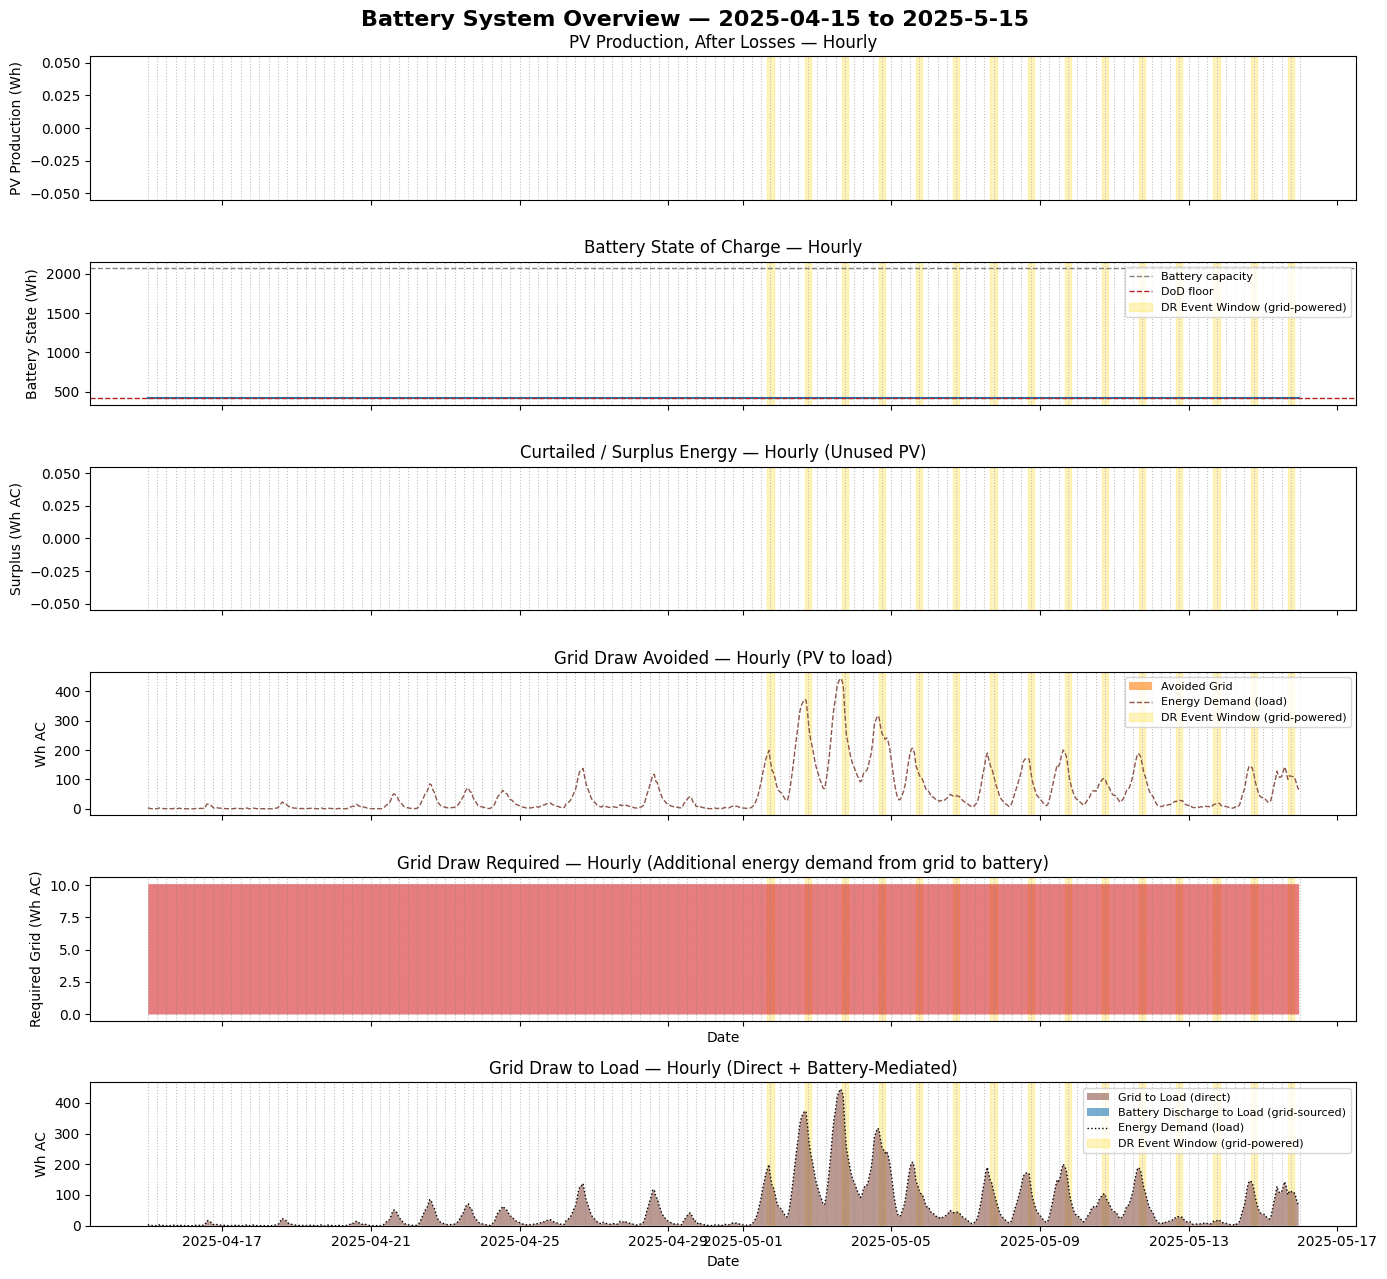

In [185]:
pv_production_arr = np.array([
    pv_to_stored_charge(getDegradedP(h, y), plugin, acToDC)
    for h in hourly_array_power_yield_test
])
idx = pd.date_range('2025-01-01', periods=len(g['batState']), freq='h')
df = pd.DataFrame(g, index=idx)
df['pvProductionWh'] = pv_production_arr
df['loadWAC'] = loadWAC
df['batteryDischargeToLoadWhAC'] = df['loadWAC'] - df['avoidedGridWhAC'] - df['grid_to_loadWhAC']
dodFloor = batWh * (1 - LiFePOdod)

# recreate the grid-window + DR-season mask the simulation used, so we can
# shade it on the plots (drWindowLengthHours must match the value
# hardcoded inside simulate_hourly_energy)
drWindowLengthHours = 4
hourOfDay = df.index.hour
dayOfYear = df.index.dayofyear
seasonEndDay = drSeasonStartDay + sum(daysInMonth) - 1
inSeason = (dayOfYear >= drSeasonStartDay) & (dayOfYear <= seasonEndDay)
inWindow = (
    (drWindowStartHour is not None)
    & (hourOfDay >= (drWindowStartHour or 0))
    & (hourOfDay < (drWindowStartHour or 0) + drWindowLengthHours)
)
df['inDRWindow'] = inSeason & inWindow

# zoom window -- 4 days
window = df.loc[window_start:window_end]

def get_event_spans(mask):
    """Collapse a boolean hourly Series into a list of (start, end) timestamp
    spans, so contiguous event hours become a single shaded block."""
    spans = []
    in_span = False
    start = None
    vals = mask.values
    times = mask.index
    for i in range(len(vals)):
        if vals[i] and not in_span:
            start = times[i]
            in_span = True
        elif not vals[i] and in_span:
            spans.append((start, times[i]))
            in_span = False
    if in_span:
        spans.append((start, times[-1] + pd.Timedelta(hours=1)))
    return spans

event_spans = get_event_spans(window['inDRWindow'])

fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True)

axes[0].fill_between(window.index, window['pvProductionWh'], color='tab:purple', alpha=0.6, linewidth=0)
axes[0].set_ylabel('PV Production (Wh)')
axes[0].set_title('PV Production, After Losses — Hourly')

axes[1].plot(window.index, window['batState'], linewidth=1.5, color='tab:blue')
axes[1].axhline(batWh, color='gray', linestyle='--', linewidth=1, label='Battery capacity')
axes[1].axhline(dodFloor, color='firebrick', linestyle='--', linewidth=1, label='DoD floor')
axes[1].set_ylabel('Battery State (Wh)')
axes[1].set_title('Battery State of Charge — Hourly')

axes[2].fill_between(window.index, window['surplusWhAC'], color='tab:green', alpha=0.6, linewidth=0)
axes[2].set_ylabel('Surplus (Wh AC)')
axes[2].set_title('Curtailed / Surplus Energy — Hourly (Unused PV)')

axes[3].fill_between(window.index, window['avoidedGridWhAC'], color='tab:orange', alpha=0.6, linewidth=0, label='Avoided Grid')
axes[3].plot(window.index, window['loadWAC'], color='tab:brown', linestyle='--', linewidth=1, label='Energy Demand (load)')
axes[3].set_ylabel('Wh AC')
axes[3].set_title('Grid Draw Avoided — Hourly (PV to load)')

axes[4].fill_between(window.index, window['requiredGridWhAC'], color='tab:red', alpha=0.6, linewidth=0)
axes[4].set_ylabel('Required Grid (Wh AC)')
axes[4].set_title('Grid Draw Required — Hourly (Additional energy demand from grid to battery)')
axes[4].set_xlabel('Date')

axes[5].stackplot(
    window.index,
    window['grid_to_loadWhAC'],
    window['batteryDischargeToLoadWhAC'],
    colors=['tab:brown', 'tab:blue'],
    alpha=0.6,
    labels=['Grid to Load (direct)', 'Battery Discharge to Load (grid-sourced)'],
)
axes[5].plot(window.index, window['loadWAC'], color='black', linestyle=':', linewidth=1, label='Energy Demand (load)')
axes[5].set_ylabel('Wh AC')
axes[5].set_title('Grid Draw to Load — Hourly (Direct + Battery-Mediated)')
axes[5].set_xlabel('Date')

# shade the DR event window on every panel
for ax_i, ax in enumerate(axes):
    for span_i, (span_start, span_end) in enumerate(event_spans):
        ax.axvspan(
            span_start, span_end,
            color='gold', alpha=0.25, zorder=0,
            label='DR Event Window (grid-powered)' if (ax_i in (1, 3, 5) and span_i == 0) else None,
        )

# vertical lines every 6 hours, across all panels, to align comparison
gridlines = pd.date_range(window.index[0].normalize(), window.index[-1] + pd.Timedelta(hours=1), freq='6h')
for ax in axes:
    for t in gridlines:
        ax.axvline(t, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

# re-issue legends now that the shaded-span label has been added
for ax in (axes[1], axes[3], axes[5]):
    ax.legend(loc='upper right', fontsize=8)

fig.suptitle(f'Battery System Overview — {window_start} to {window_end}', fontsize=16, fontweight='bold')
plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f'outputs/tests/battery_system_overview_{window_start}_{window_end}_{plugin}_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

### Plot used in paper to demonstrate control scheme

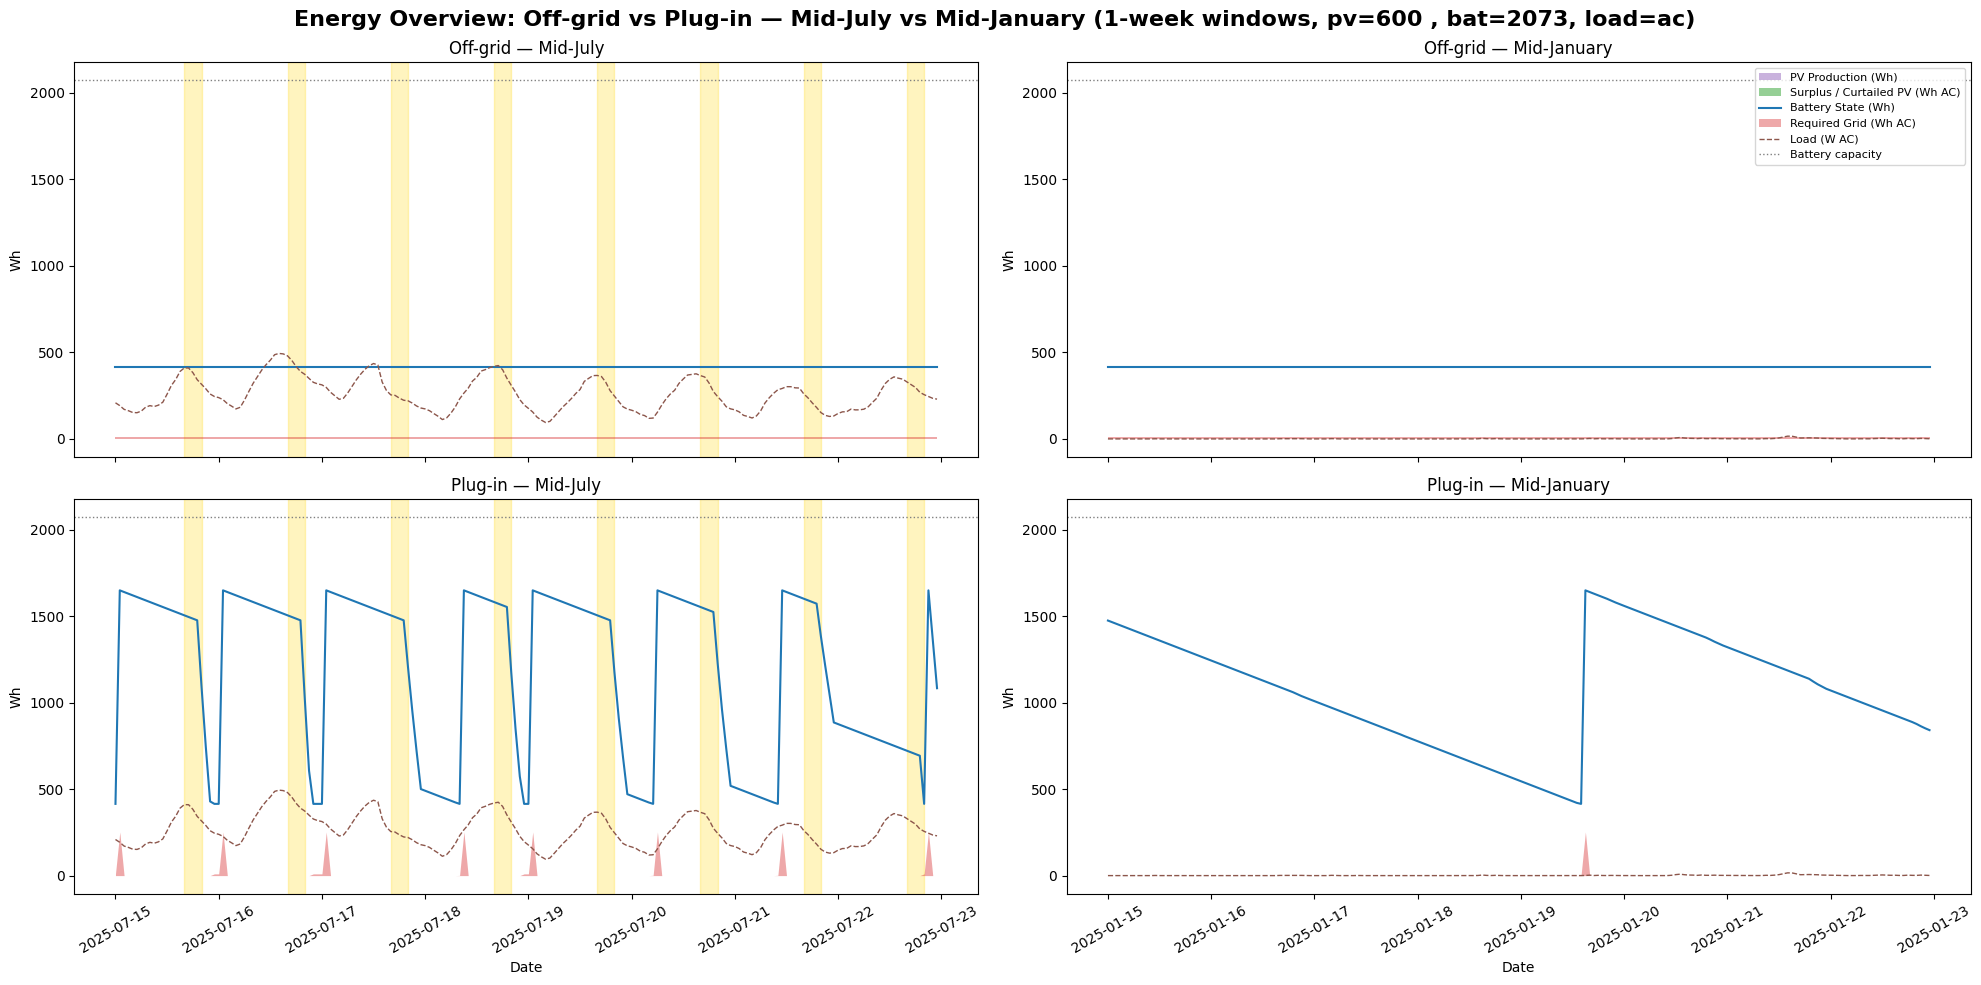

In [186]:
# 4-subplot overview: Off-grid vs Plug-in, Mid-July vs Mid-January (1-week windows each)

week_windows = {
    'Mid-July': ('2025-07-15', '2025-07-22'),
    'Mid-January': ('2025-01-15', '2025-01-22'),
}
plugin_configs = [('Off-grid', False), ('Plug-in', True)]

fig, axes2 = plt.subplots(2, 2, figsize=(20, 10), sharex='col')

for row, (config_label, config_plugin) in enumerate(plugin_configs):
    g2 = simulate_hourly_energy(
        list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, config_plugin,
        drWindowStartHour=drWindowStartHour,maxDischargeRateW=600
    )
    pv_production_arr2 = np.array([
        pv_to_stored_charge(getDegradedP(h, y), config_plugin, acToDC)
        for h in hourly_array_power_yield_test
    ])
    idx2 = pd.date_range('2025-01-01', periods=len(g2['batState']), freq='h')
    df2 = pd.DataFrame(g2, index=idx2)
    df2['pvProductionWh'] = pv_production_arr2
    df2['loadWAC'] = loadWAC

    # recreate the grid-window + DR-season mask, same logic as the cell above
    hourOfDay2 = df2.index.hour
    dayOfYear2 = df2.index.dayofyear
    seasonEndDay2 = drSeasonStartDay + sum(daysInMonth) - 1
    inSeason2 = (dayOfYear2 >= drSeasonStartDay) & (dayOfYear2 <= seasonEndDay2)
    inWindow2 = (
        (drWindowStartHour is not None)
        & (hourOfDay2 >= (drWindowStartHour or 0))
        & (hourOfDay2 < (drWindowStartHour or 0) + drWindowLengthHours)
    )
    df2['inDRWindow'] = inSeason2 & inWindow2

    for col, (window_label, (w_start, w_end)) in enumerate(week_windows.items()):
        ax = axes2[row, col]
        window2 = df2.loc[w_start:w_end]
        event_spans2 = get_event_spans(window2['inDRWindow'])

        ax.fill_between(window2.index, window2['pvProductionWh'], color='tab:purple', alpha=0.5,
                         linewidth=0, label='PV Production (Wh)')
        ax.fill_between(window2.index, window2['surplusWhAC'], color='tab:green', alpha=0.5,
                         linewidth=0, label='Surplus / Curtailed PV (Wh AC)')
        ax.plot(window2.index, window2['batState'], color='tab:blue', linewidth=1.5,
                label='Battery State (Wh)')
        ax.fill_between(window2.index, window2['requiredGridWhAC'], color='tab:red', alpha=0.4,
                         linewidth=0, label='Required Grid (Wh AC)')
        ax.plot(window2.index, window2['loadWAC'], color='tab:brown', linestyle='--', linewidth=1,
                label='Load (W AC)')
        ax.axhline(batWh, color='gray', linestyle=':', linewidth=1, label='Battery capacity')

        for span_start, span_end in event_spans2:
            ax.axvspan(span_start, span_end, color='gold', alpha=0.25, zorder=0)

        ax.set_title(f'{config_label} — {window_label}')
        ax.set_ylabel('Wh')
        if row == 1:
            ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=30)

axes2[0, 1].legend(loc='upper right', fontsize=8)

fig.suptitle(f'Energy Overview: Off-grid vs Plug-in — Mid-July vs Mid-January (1-week windows, pv={pvW} , bat={batWh}, load={loadName})',
             fontsize=16, fontweight='bold')
plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f'outputs/tests/offgrid_plugin_seasonal_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

## Economic Modeling & Hardware Costs

Components:

* CAPEX
* Grid electricity value (costs or avoided value)
* PBP
* NPV
* IRR
* LCOE (LCOSS)

In [187]:
# #average inflation rate for 2024, based on NREL data from https://atb.nrel.gov/electricity/2024/definitions#inflation
# aIR = 0.025

realDiscountRate = 0.03 # 43 #2.2% real rate
# nominalDiscountRate = ((1 + realDiscountRate) * (1 + aIR))-1
# print(nominalDiscountRate)
discountRate = realDiscountRate #2% discount rate

# #returns inflation rate after Y years
# #args: year
# def infRate(y, r= aIR):
#     return (1+r)**y

# arguments: value to be inflated, year
# not used
def inflateIt(v,y):
    return v* infRate(y)

avgAnnualInc= 0.02
def annualCostIncrease(v,y):
    return v* ((1+avgAnnualInc)**y)
    
#args: value to be discounted, year
def discountIt(v, y,r =discountRate):
    return v/(1+r)**y

#inflateIt(10,4)

### Capital Expenses (CAPEX) i.e. upfront costs

In [188]:
# Upfront Costs

#args: pv watts
def getPVcost(w:int):
    #.7 is based on a 30% tax credit on PV modules
    taxCredit = 0 #.3 #IRA repealed by Trumps BS
    #assumes $0.5 per W modules
    modulePerW = 0.5

    return w * (1-taxCredit) * modulePerW

#this is the total initial expenditure
#args: pv watts, battery price, diy controller,  micro-inverter in use, operating expense
def getCAPEX(pvW:int,batPr:float,diy:bool=True,mi:bool=False,op:float=0.0):
    #total sales tax in NYC is 8.875% - no sales tax for non-profits
    salesTax =  0.08875 

    if pvW == 0:
        #fixed costs
        insulation = 0 #used for insulating cable entry
        pvCables = 0 #2x 10ft MC4 cables
    else:
        #fixed costs
        insulation = 6 #used for insulating cable entry
        pvCables = 1.5 * 20 #20ft pair MC4 cables @ $1.5/ft

    #variable costs
    mountDollarPerW = .4

    smartController = 0
    if diy:
        smartController = 115.74 #smart controller without RPi

    microinverter = 0
    if mi:
        microinverter = 325 #Price as on July 2026 - https://usa.apsystems.com/product/ez1-microinverter/

    rpi = 0
    if mi or diy:
        rpi = 62.75
        
        
    operatingCosts = op #DR aggregation operator costs are not considered here.
    
    fixedHardwareCosts = smartController + rpi + operatingCosts + insulation + pvCables + microinverter

    variableCosts = batPr + getPVcost(pvW) + (pvW * mountDollarPerW)

    return (fixedHardwareCosts + variableCosts) * (1 + salesTax)

#print(getCAPEX(100,200))


### Grid Electricity Costs

In [189]:
# GRID ELECTRICITY COSTS - CHANGE THIS TO JULY AND AUGUST AVG FOR ELEX!

# https://www.bls.gov/regions/northeast/news-release/averageenergyprices_newyork.htm accessed January 24, 2025
#monthlyResElecPricesDollars = [0.265,0.255,0.266,0.259,0.252,0.288,0.288,0.276,0.273,0.274,0.262,0.272]

# https://www.nyserda.ny.gov/Energy-Prices/Electricity/Monthly-Avg-Electricity-Residential
monthlyResElecPricesDollars = [0.284, 0.30, 0.286,0.2879,0.299,0.2979,0.2934,0.299,0.3046,0.3024,0.2957,0.3069]
#monthlyResElecPricesDollars = [0,0,0,0,0,0,0,0,0,0,0,0]

avgDollarsKw =round(sum(monthlyResElecPricesDollars)/len(monthlyResElecPricesDollars),4) 
print('12 Month NYS Residential Retail Electricity Average: $' + str(avgDollarsKw) + '/kWh')

#args: kWAC generated from PV, year from installation, month (either a for all or the number of the month-1)
def utilityCosts(kWAC,y=0, m='a'):

    if m=='a':
        price =round(sum(monthlyResElecPricesDollars)/len(monthlyResElecPricesDollars),4) 
    else:
        price=monthlyResElecPricesDollars[m]

    annualElectCosts = kWAC * annualCostIncrease(price,y) # this factors in annual grid price increases
    return annualElectCosts

print(utilityCosts(15,3))

12 Month NYS Residential Retail Electricity Average: $0.2964/kWh
4.718130768000001


In [190]:
def aggregate_hourly_to_monthly(hourly, year=2025):
    """
    Convert raw hourly arrays (already AC-equivalent Wh) into monthly kWAC
    surplus stats and annual totals, using a datetime index.

    avg/med/min/max_hourly_surpluskWAC_byMonth are computed as true daily
    averages of surplus hours (zero-surplus hours excluded from the
    per-day stat, matching the original per-day loop's behavior), then
    those daily stats are aggregated across each month.
    """
    idx = pd.date_range(start=f'{year}-01-01', periods=len(hourly['surplusWhAC']), freq='h')
    surplus = pd.Series(hourly['surplusWhAC'], index=idx) * 0.001  # Wh -> kWAC

    # NaN on zero-surplus hours so daily stats skip them, like the original
    surplus_nonzero = surplus.where(surplus > 0)
    daily_avg = surplus_nonzero.resample('D').mean().fillna(0)
    daily_med = surplus_nonzero.resample('D').median().fillna(0)
    daily_min = surplus_nonzero.resample('D').min().fillna(0)
    daily_max = surplus_nonzero.resample('D').max().fillna(0)
    daily_totals = surplus.resample('D').sum()

    return {
        'avg_hourly_surpluskWAC_byMonth': daily_avg.resample('ME').mean().tolist(),
        'med_hourly_surpluskWAC_byMonth': daily_med.resample('ME').median().tolist(),
        'min_hourly_surpluskWAC_byMonth': daily_min.resample('ME').min().tolist(),
        'max_hourly_surpluskWAC_byMonth': daily_max.resample('ME').max().tolist(),
        'ann_surpluskWhAC': daily_totals.sum(),
        'requiredGridWhAC_total': hourly['requiredGridWhAC'].sum(),
        'avoidedGridWhAC_total': hourly['avoidedGridWhAC'].sum(),
        'gridToLoadWhAC_total': hourly['grid_to_loadWhAC'].sum(),
    }

def apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE):
    """
    Convert aggregated AC-equivalent energy totals into dollar values.
    No unit conversion happens here anymore — that's already done
    upstream in simulate_hourly_energy.
    """
    requiredGridkWhAC = agg['requiredGridWhAC_total'] * 0.001
    avoidedGridkWhAC = agg['avoidedGridWhAC_total'] * 0.001
    gridToLoadkWhAC = agg['gridToLoadWhAC_total'] * 0.001

    # top off from grid for events — round-trip conversion loss vs. going
    # direct from grid to load
    eventGridCharge_kWhAC = events * ((batWh * LiFePOdod_event * 0.001) / acToDC) 
    eventBatteryOutputkWhAC_fromGrid = eventGridCharge_kWhAC * acToDC * iE

    return {
        'avg_hourly_surpluskWAC_byMonth': agg['avg_hourly_surpluskWAC_byMonth'],
        'med_hourly_surpluskWAC_byMonth': agg['med_hourly_surpluskWAC_byMonth'],
        'min_hourly_surpluskWAC_byMonth': agg['min_hourly_surpluskWAC_byMonth'],
        'max_hourly_surpluskWAC_byMonth': agg['max_hourly_surpluskWAC_byMonth'],
        'ann_surpluskWhAC': agg['ann_surpluskWhAC'],
        'ann_surpluskWhAC_value': utilityCosts(agg['ann_surpluskWhAC'], y),
        'requiredGridkWhAC': requiredGridkWhAC,
        'requiredGridkWhAC_cost': utilityCosts(requiredGridkWhAC, y),
        'eventGridChargekWhAC': eventGridCharge_kWhAC,
        'eventGridChargekWhAC_cost': utilityCosts(eventGridCharge_kWhAC,y,6), #base the cost off of July rates
        'eventBatteryOutputkWhAC_fromGrid': eventBatteryOutputkWhAC_fromGrid,
        'avoidedGridkWhAC': avoidedGridkWhAC,
        'avoidedGridkWhAC_value': utilityCosts(avoidedGridkWhAC, y),
        'gridToLoadkWhAC': gridToLoadkWhAC,
    }

def getGridValueHourly(pvYieldW, batWh, loadWAC, iE, events=5, y=0, plugin=True,
                       drWindowStartHour=None, maxChargeRateW=1800, maxDischargeRateW=None,
                       dlrpStartHours=None):
    """
    drWindowStartHour, maxChargeRateW, maxDischargeRateW: passed straight
    through to simulate_hourly_energy (see its docstring) so the grid-window
    and AC-side hardware rate caps are reflected in the financial totals too.

    dlrpStartHours: optional dict of {label: event_start_hour}, e.g.
    {'c': dlrpStartC, 'i': dlrpStartI}. When provided, the batState
    already produced by this call's simulate_hourly_energy run is also
    sampled via batteryStateAtEvent at each labeled hour (and 2 hours
    before it), and the by-month results are folded into the returned
    dict as 'dlrpBatState_atEventStart_{label}' and
    'dlrpBatState_beforeEventStart_{label}'. This lets DLRP event-start
    battery capacity be computed per load, using that load's own
    simulated cycling behavior, without running a second simulation.
    """
    n_hours = len(pvYieldW)
    loadWAC_hourly = build_seasonal_load_array(loadWAC, n_hours=n_hours)

    hourly = simulate_hourly_energy(
        pvYieldW, batWh, loadWAC_hourly, iE, y, plugin,
        dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
        LiFePOdod=LiFePOdod, acToDC=acToDC,
        drWindowStartHour=drWindowStartHour,
        maxChargeRateW=maxChargeRateW,
        maxDischargeRateW=maxDischargeRateW,
    )
    agg = aggregate_hourly_to_monthly(hourly)
    result = apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE)

    if dlrpStartHours:
        for label, sT in dlrpStartHours.items():
            bse = batteryStateAtEvent(hourly['batState'], round(sT))
            result[f'dlrpBatState_atEventStart_{label}'] = bse['atEventStart']
            result[f'dlrpBatState_beforeEventStart_{label}'] = bse['beforeEventStart']

    return result

In [191]:
getGridValueHourly(list(hourly_array_power_yield_test), 0,100,.85)

{'avg_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'med_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'min_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'max_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'ann_surpluskWhAC': np.float64(0.0),
 'ann_surpluskWhAC_value': np.float64(0.0),
 'requiredGridkWhAC': np.float64(0.0),
 'requiredGridkWhAC_cost': np.float64(0.0),
 'eventGridChargekWhAC': 0.0,
 'eventGridChargekWhAC_cost': 0.0,
 'eventBatteryOutputkWhAC_fromGrid': 0.0,
 'avoidedGridkWhAC': np.float64(0.0),
 'avoidedGridkWhAC_value': np.float64(0.0),
 'gridToLoadkWhAC': np.float64(367.2)}

### Payback Period

Payback Period = Initial Investment / Annual Value

In [192]:
#args: capex, grid value, DR revenue
# returns PBP in years
def getPBP(c:float,g:Dict[str,List[float]],dr:list[float])->Dict[str,float]:
    # gK = ['requiredGridkWhAC_cost','eventGridChargekWhAC_costs','avoidedGridkWhAC_value']
    # gKS = ['ann_surpluskWhAC_value']
    
    pbp = {'without_surplus':0,'with_surplus':0}
    avgDr = mean(dr)
    
    gridBalance = mean(g['avoidedGridkWhAC_value']) - mean(g['requiredGridkWhAC_cost']) - mean(g['eventGridChargekWhAC_cost'])
    pbp['without_surplus'] = c/(gridBalance+avgDr)
    pbp['with_surplus'] = c/(gridBalance+avgDr+mean(g['ann_surpluskWhAC_value']))

    return pbp
    
# cTest =  300
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0, 'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)], 'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)], 'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)], 'eventGridChargekWhAC_cost': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)], 'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)], 'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# drTest = [np.float64(8.32920429661677), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(3.1849880941306794), 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, np.float64(15.656175588316744), 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0]
#getPBP(cTest,gTest,drTest)

### Net Present Value (NPV)

NPV = ∑ (Cash flow / (1 + i)^t) – initial investment

In [193]:
# args: capex, grid value, dr value
def getNPV(c, g, dr):
    subC = -1 * c
    npv = {'without_surplus':subC,'with_surplus':subC}
    wl = min(10, len(dr))
    
    for y in range(wl):
        cashFlow = g['avoidedGridkWhAC_value'][y] - g['requiredGridkWhAC_cost'][y] - g['eventGridChargekWhAC_cost'][y] +dr[y]
        npv['without_surplus'] += (discountIt(cashFlow,y))
        npv['with_surplus'] += (discountIt(cashFlow+g['ann_surpluskWhAC_value'][y],y)) 
    return npv

# cTest =  300
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0, 'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)], 'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)], 'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)], 'eventGridChargekWhAC_cost': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)], 'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)], 'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# drTest = [np.float64(8.32920429661677), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(3.1849880941306794), 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, np.float64(15.656175588316744), 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0]
# getNPV(cTest,gTest,drTest)

In [194]:
# args: capex, grid value, dr value
# returns the discount rate at which NPV == 0 -- mirrors getNPV's own cash
# flow definition and (1+r)^y timing convention exactly (including that
# year y=0's cash flow is undiscounted, same as capex), so the IRR
# reported here is consistent with the NPV/PBP numbers for the same row.
# No external dependency (e.g. numpy_financial): solved with bisection.
def getIRR(c, g, dr, r_lo=-0.99, r_hi=10.0, tol=1e-6, max_iter=200):
    wl = min(10, len(dr))

    def npv_at_rate(r, surplus):
        npv = -1 * c
        for y in range(wl):
            cashFlow = g['avoidedGridkWhAC_value'][y] - g['requiredGridkWhAC_cost'][y] - g['eventGridChargekWhAC_cost'][y] + dr[y]
            if surplus:
                cashFlow += g['ann_surpluskWhAC_value'][y]
            npv += cashFlow / (1 + r) ** y
        return npv

    def solve(surplus):
        lo, hi = r_lo, r_hi
        f_lo, f_hi = npv_at_rate(lo, surplus), npv_at_rate(hi, surplus)

        # no real IRR in this bracket -- e.g. cash flows never recover the
        # initial capex (NPV stays negative at every rate), or there's no
        # capex to recover at all
        if f_lo == 0:
            return lo
        if f_hi == 0:
            return hi
        if (f_lo > 0) == (f_hi > 0):
            return float('nan')

        mid = lo
        for _ in range(max_iter):
            mid = (lo + hi) / 2
            f_mid = npv_at_rate(mid, surplus)
            if abs(f_mid) < tol or (hi - lo) < tol:
                return mid
            if (f_mid > 0) == (f_lo > 0):
                lo, f_lo = mid, f_mid
            else:
                hi = mid
        return mid

    return {
        'without_surplus': solve(False),
        'with_surplus': solve(True),
    }

### Levelized Cost of Solar plus Storage (LCOSS)

Total Costs ($)/ Total Energy (kWAC)

In [195]:
#returns the dollar value of the module at the end of the system's working like
# factors in module degradation 
# args: PV watts nameplate,year
def getResidualValue(w,y):
     return getPVcost(getDegradedP(w,y)) #inflateIt(getPVcost(getDegradedP(w,y)),y)
 
#test
#getResidualValue(100, 8.3)

In [196]:
# capex, gridValue, pv watts, constant load W
def getLCOSS(c, g, w, totalLoadkWhAC):
    resVal = getResidualValue(w, min(len(d), 10))
    wl = len(g['avoidedGridkWhAC_value'])
    #totalLoadkWhAC = loadWAC * 8760 * 0.001

    lcoss = {'without_surplus': 0, 'with_surplus': 0}

    for variant in lcoss:
        num = c - discountIt(resVal, wl - 1)
        den = 0
        for y in range(wl):
            num += discountIt(g['requiredGridkWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y], y)

            selfSuppliedkWhAC = totalLoadkWhAC - g['gridToLoadkWhAC'][y]

            # self supplied is only not used in off-grid mode when PV=0, in this situation it defaults to the battery output for the events only
            energy = max(selfSuppliedkWhAC,g['eventBatteryOutputkWhAC_fromGrid'][y])
                
            if variant == 'with_surplus':
                energy += g['ann_surpluskWhAC'][y]
            den += discountIt(energy, y)

        lcoss[variant] = num / den if den != 0 else float('nan')

    return lcoss

In [197]:
#getLCOSS(cTest,gTest,wTest,sYTest,eETest) 

## Automated DR Participation

In [198]:
# returns the max value for a given load - does not consider the ability to meet the load needs
def drMaxValue(loadW_C,loadW_D, cRate, dRate, prefix=''):
    m=5 # months in the DR season
    annValResProgram_csrp = loadW_C * .001 * cRate * m #CSRP reservation value for full coverage of load
    annValResProgram_dlrp = loadW_D * .001 * dRate * m #DLRP reservation value for full coverage of load
    annValResTot = annValResProgram_csrp + annValResProgram_dlrp # Total DR reservation value for full coverage
    annValPer_csrp = loadW_C * .001 * csrpEvents #CSRP performance value for full coverage of load
    annValPer_dlrp = loadW_D * .001 * dlrpEvents #DLRP performance value for full coverage of load
    annValPer = annValPer_csrp + annValPer_dlrp #total performance value for full coverage of load
    annTotVal = annValResTot + annValPer # total value for full coverage of load

    drv = {
        f"{prefix}annValResProgram_csrp" : annValResProgram_csrp,
        f"{prefix}annValResProgram_dlrp" : annValResProgram_dlrp,
        f"{prefix}annValResTot" : annValResTot,
        f"{prefix}annValPer_csrp" : annValPer_csrp,
        f"{prefix}annValPer_dlrp" : annValPer_dlrp,
        f"{prefix}annValPer" : annValPer,
        f"{prefix}annTotVal" : annTotVal
    }
    return drv

# returns power that can be addressed and the annual dollar value
def drFlexValue(drkWACtotal_y, loadkW, rate, eventNum, replacement_kW=0, prefix=''):
    res = {}
    if replacement_kW ==0:
        flexedkW = min(drkWACtotal_y,loadkW) #kWAC flexed up to baseline
        resInc = flexedkW * rate * eventNum # annual reservation income
        perfInc = flexedkW * 4 * eventNum # annual performance income - $1/kWh
    else:
        perc = drkWACtotal_y/replacement_kW # percentage of load covered
        flexedkW = loadkW * min(1,perc)  # the replacement is scaled based on the percentage of the event the replacement load can run for
        resInc = flexedkW * rate * eventNum# annual reservation income
        perfInc = flexedkW * 4 * eventNum # annual performance income (rate is $1/kWh)
    res['inc'] = resInc + perfInc
    res['flex'] = flexedkW
    return res

In [199]:

#get the available hourly watts if the battery is fully depleted over 4 hours
#arg: battery WhDC
# no longer used
def getFourHourW(bWh:float):
    return bWh * LiFePOdod * .25

In [200]:
def solarEventYieldkWAC(pvWyield, iE, sT, year=0, plugin=False) -> list:
    #daysInMonth = [31, 30, 31, 31, 30]
    elapsedDays = drSeasonStartDay  # May 1

    eff_mult = 1.0 if plugin else iE
    degrade = (1 - DEG_RATE) ** year   # <-- computed once, not per-hour

    monthly = []
    for dim in daysInMonth:
        # build hour indices for the 4 event hours, every day in this month
        day_starts = ((np.arange(elapsedDays, elapsedDays + dim) - 1) * 24) + sT
        hour_idx = day_starts[:, None] + np.arange(4)   # shape (dim, 4)
        window = pvWyield[hour_idx]                      # shape (dim, 4)

        daily_kwh = window.sum(axis=1) * eff_mult * 0.001 * 0.25  # per-day event kWh
        monthly.append(daily_kwh.mean())

        elapsedDays += dim

    # apply degradation once at the end, to every month at once
    return [m * degrade for m in monthly]

def batteryStateAtEvent(batState, sT, offsetHours=2) -> dict:
    """
    Returns the average *simulated* battery state (Wh), by month, at the
    DR event start hour and offsetHours hours before it.

    batState: hourly battery-state array (Wh) for a single simulated
    year, as returned by simulate_hourly_energy under the 'batState' key.
    This reflects actual day-to-day charge/discharge cycling (driven by
    the load, PV, and grid-window behavior already modeled in
    simulate_hourly_energy), replacing the old PV-yield-only proxy
    (solarPriorEventYieldWDC, removed).

    sT: event start hour of day (0-23). Round fractional start times
    (e.g. 16.5) before calling, same convention as solarEventYieldkWAC.
    offsetHours: how many hours before the event start to also sample
    (default 2, matching the DR programs' notice window).
    """
    elapsedDays = drSeasonStartDay

    atEventStart = []
    beforeEventStart = []
    for dim in daysInMonth:
        day_starts = (np.arange(elapsedDays, elapsedDays + dim) - 1) * 24
        idx_start = day_starts + sT
        idx_before = day_starts + max(sT - offsetHours, 0)

        atEventStart.append(batState[idx_start].mean())
        beforeEventStart.append(batState[idx_before].mean())

        elapsedDays += dim

    return {
        'atEventStart': atEventStart,
        'beforeEventStart': beforeEventStart,
    }

## Main Loop

This loop generates all the possible combinations of hardware and their energy and economic characteristics based on the constraints of the battery. 

In [201]:
#these networks are selected because they represent all possible combinations of characteristics

#myNetworks2023 = ['city hall','long island city','crown heights','randalls island', 'millwood west', 'grasslands','fresh kills','central bronx','northeast bronx']

In [202]:
yieldData = getYieldData(tilt, gamma_pdc)
#print(yieldData['180']['40'])

In [203]:
# check structure of output from above if needed
def key_outline(obj, indent=0):
    if isinstance(obj, dict):
        for k, v in obj.items():
            print("  " * indent + str(k))
            key_outline(v, indent + 1)
    elif isinstance(obj, pd.DataFrame):
        print("  " * indent + f"[DataFrame columns: {list(obj.columns)}]")
    elif isinstance(obj, (list, tuple)) and obj:
        key_outline(obj[0], indent + 1)

#key_outline(yieldData)

In [231]:
# True = quick test, false = full run
testMode = True
testModeNetworks = testMode
testModeBatteries = True
testModeAzimuth = True
testModePV = testMode
testModeF = True
testModeMI = True

# print('test mode: ' + str(testMode))

# print('loop start time:')
# print(datetime.now())

# network max DR values ($) by load scenario
nData = {
        'network':[],
        'load1W':[],
        'load2W':[],
        'load1RW':[],
        'l1_annValResProgram_csrp' : [],
        'l1_annValResProgram_dlrp' : [],
        'l1_annValResTot':[],
        'l1_annValPer_csrp' : [],
        'l1_annValPer_dlrp' : [],
        'l1_annValPer' : [],
        'l1_annTotVal' : [],
        'l2_annValResProgram_csrp' : [],
        'l2_annValResProgram_dlrp' : [],
        'l2_annValResTot':[],
        'l2_annValPer_csrp' : [],
        'l2_annValPer_dlrp' : [],
        'l2_annValPer' : [],
        'l2_annTotVal' : []
        }

rData = {
        'network':[],
        'eventStart':[],
        'dlrp_rate':[],
        'csrp_rate':[],
        'az':[],
        'pvW':[],
        'microinverter':[],
        'batModel':[],
        'batWh_80p':[],
        'batWhAC_80p':[],
        'effEff':[],#effective real efficiency
        'dischargeRateW':[],
        'capex':[],

        'cycles':[],
        'lifespan':[],
        'workingLife':[],
        'dailyPVWhAC_4M':[], #year 1 PV yields AC: min, max, mean, median
        'annualPVkWhDC_degraded':[],
        'annualPVkWhAC_degraded':[],
        'immediateEventAmt':[],

        'csrpMaxFlex':[],
        'csrpLoad1_flex':[],
        'csrpLoad2_flex':[],
        'csrpLoad1replacement_flex':[],
        'csrpLoad1Income':[],
        'csrpLoad2Income':[],
        'csrpLoad1RIncome':[],

        'dlrpMaxFlex':[],
        'dlrpLoad1_flex':[],
        'dlrpLoad2_flex':[],
        'dlrpLoad1replacement_flex':[],
        'dlrpLoad1Income':[],
        'dlrpLoad2Income':[],
        'dlrpLoad1RIncome':[],

        'annDRIncomeLoad1': [],
        'annDRIncomeLoad2': [],
        'annDRIncomeLoad1R': [],

        'gridValue_load1':[],
        'gridValue_load2':[],
        'gridValue_load1R':[],
        
        'load1_NPV':[],
        'load2_NPV':[],
        'load1R_NPV':[],
    
        'load1_PBP':[], #real rate of return includes inflation and PV degradation (does not include discount rate)
        'load2_PBP':[],
        'load1R_PBP':[],

        'load1_IRR':[],
        'load2_IRR':[],
        'load1R_IRR':[],

        'load1_LCOSS':[],
        'load2_LCOSS':[],
        'load1R_LCOSS':[],

        # capex sensitivity -- each cell holds a dict keyed by capex
        # multiplier, e.g. {-0.2: {'without_surplus':.., 'with_surplus':..}, 0.0: {...}, ...}
        'load1_PBP_capexSensitivity':[],
        'load2_PBP_capexSensitivity':[],
        'load1R_PBP_capexSensitivity':[],

        'load1_NPV_capexSensitivity':[],
        'load2_NPV_capexSensitivity':[],
        'load1R_NPV_capexSensitivity':[],

        'load1_IRR_capexSensitivity':[],
        'load2_IRR_capexSensitivity':[],
        'load1R_IRR_capexSensitivity':[],

        'load1_LCOSS_capexSensitivity':[],
        'load2_LCOSS_capexSensitivity':[],
        'load1R_LCOSS_capexSensitivity':[]
    }

In [232]:
print('Go!')

Go!


In [250]:
'''
keys questions
PV usage all year round -> avoided grid costs?
battery % gaurantees
impact of controls (does this need a test?)
'''
print(f'Test mode: {testMode}')
st = datetime.now()
print(f'loop start time:{st}')
print('')

# reset rData just in case
for k,v in rData.items():
    rData[k] = []

capexMultipliers = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

csrpEvents = 4 # number of CSRP events annually
dlrpEvents = 1 # number of DLRP events annually
months = 5 # number of months DR programs run
programs = 2 # number of programs

years = 10 # max years

#diyBool = False

# also run it for max load
# loadOneW = 500 # AC
# loadTwoW = 100 # fridge
# loadOneW_Replacement = 80 # Fan

# loads = {'loadOneW':1000, # AC
#         'loadTwoW':100, # fridge
#         'loadOneW_Replacement':75} # fan


######################
##### TEST SETUP #####
######################
loopCount = []
loopNumber = 0

if testModeNetworks:
    myNetworks = ['bowling green','sunnyside','borden','fresh kills']
else:
    #these networks are selected because they represent all possible combinations of characteristics
    myNetworks = ['bowling green','borden','sunnyside','grasslands','fresh kills','park slope', 'fordham', 'central bronx']

#loop through all networks
loopCount.append(len(myNetworks))

if testModeBatteries:
    bRange = [28]#range(16,29)
else:  
    bRange = range(hardware_df.shape[0])
loopCount.append(len(bRange))

if testModePV:
    pRange = [0]#,100,800]#range(0,30,10)
else:
    #loop through all allowed PV modules sizes, incrementing by 20W
    pRange = range(0,pvMaxW +50,50)
loopCount.append(len(pRange))

if testModeAzimuth: #) or (pW == 0):
    aRange = [180]
else:
    #loop through 3 azimuths
    aRange = [110,180,250]
loopCount.append(len(aRange))

if testModeF:
    fRange = [0]
else:
    fRange = [0,1,6]
loopCount.append(len(fRange))

if testModeMI:
    miRange = [False]
else:
    miRange = [True,False]
loopCount.append(len(miRange))

# ---- accurate loop count, respecting the Max PV Watts skip ----
# for each battery, count how many pW values in pRange it can actually support
validPVCountsPerBattery = []
for b in bRange:
    maxPVW = hardware_df.iloc[b]['Max PV Watts']
    validPVCountsPerBattery.append(sum(1 for pW in pRange if pW <= maxPVW))

# networks * mi * aRange * fRange are independent of the skip,
# only pRange x battery combos are filtered
loopCountInt = (
    len(myNetworks)
    * len(miRange)
    * len(aRange)
    * len(fRange)
    * sum(validPVCountsPerBattery)
)


dlrpStartC = 16 # needed for estimating PV contribution
dlrpStartI = 16.25 # needed for estimating PV contribution
####################
##### RUN TEST #####
####################
for n in myNetworks:
    
    print(n)
    startTime = getStartTime(n) #CSRP assigned start time

    loadOneW_Cevent_W = event_window_max(loads['loadOneW'], startTime)
    loadTwoW_Cevent_W = event_window_max(loads['loadTwoW'], startTime)
    print(f'loadOneW_Cevent_W:{loadOneW_Cevent_W}')
    loadOneW_Devent_W = event_window_max(loads['loadOneW'], dlrpStartC)
    loadTwoW_Devent_W = event_window_max(loads['loadTwoW'], dlrpStartC)

    #monthly income from DR participation
    #the DR rate for each program
    dlrp_rate= getDLRPrate(n)
    csrp_rate = getCSRPrate(n)

    loadOneDR = drMaxValue(max(loadOneW_Cevent_W), max(loadOneW_Devent_W), csrp_rate, dlrp_rate, "l1_")
    loadTwoDR = drMaxValue(max(loadTwoW_Cevent_W), max(loadTwoW_Devent_W), csrp_rate, dlrp_rate, "l2_")
    
    ###### package network data (hardware agnostic) #########
    nData['network'].append(n)
    #nData['load1W'].append(loads['loadOneW'])
    #nData['load2W'].append(loads['loadTwoW'])
    nData['load1W'].append(np.mean(loads['loadOneW']))
    nData['load2W'].append(np.mean(loads['loadTwoW']))
    nData['load1RW'].append(loads['loadOneW_Replacement'])
    #merged = {**dict2, **dict1}
    # nData['load1MaxDRInc'].append(loadOneDR)
    # nData['load2MaxDRInc'].append(loadTwoDR)

    # Unpack loadTwoDR into nData
    for k, v in loadOneDR.items():
        nData[k].append(v)
    # Unpack loadTwoDR into nData
    for k, v in loadTwoDR.items():
        nData[k].append(v)

    #loop through all batteries in database
    for b in bRange:

        #print('')
        #get battery info - controllable devices only
        d = hardware_df.iloc[b]
        #print(d)
    
        bWh = d['Battery Wh']
        bModel = d['Model']
        
        #time in hours it takes to charge the battery
        #from 0% to 100% from the grid
        bCT = d['Full Grid Charge Hours']
        #from 80% to 100% from grid
        bFCT = d['Full Grid Charge Hours']-d['80 Per Grid Charge Hours']
        #the charge time from 20% to 100%
        practicalBCT = (d['80 Per Grid Charge Hours'] * .75) + bFCT #this is what we care about for DR
        #print(f'20-100% Charge Time: {round(practicalBCT,3)} hours')

        #convert to AC
        #battery is depleted 80% at 4-hour rate
        fH = bWh * LiFePOdod * .25 # getFourHourW(bWh) 
        
        #effective efficiency is the actualy efficiency when consuming power at the 4 hour rate
        effectiveEfficiency = d['Inverter Efficiency']


        # AC-side hardware rate caps for simulate_hourly_energy (via getGridValueHourly):
        # charging cap = charger's rated AC input; falls back to the function's own
        # default (1800) when the hardware table has no value for this unit.
        # discharging cap = inverter's rated AC output (same field already used above
        # to check whether the inverter can support a given load).
        maxChargeRateW_hw = d['Max AC Input Watts'] if pd.notna(d['Max AC Input Watts']) else 1800
        maxDischargeRateW_hw = d['Inverter Watts'] if pd.notna(d['Inverter Watts']) else None
        
        #bat capacity down to DoD
        realBWh = bWh * LiFePOdod
        realBWh_event = bWh * LiFePOdod_event
        
        #bat WhAC capacity
        bWhAC = realBWh * effectiveEfficiency
        #print(f'Battery Capacity: {round(bWhAC,3)} WhAC')

        #life span assumes 1 full cycle a day
        lS = d['Cycles']/365
        #working life caps the lifespan at 10 years
        wL = min(10,lS)
        wLrounded = math.ceil(wL) # round wL up for some calculations

        # include plug-in micro inverter in model
        for m in miRange:
            miBool = m
            
            for pW in pRange:
    
                #if the array exceeds the power station capacity, skip it
                if pW > d['Max PV Watts']:
                    continue
    
                #Hardware Costs in Dollars
                diyBool = not d['official API']
                capex =getCAPEX(pW,d['retail price'],diyBool,miBool)
        
                for a in aRange:
    
                    ################
                    ###### PV ######
                    ################
                    
                    csrpPV_kWAC = [] # avg PV production during event, by month 
                    #dlrpPV_kWAC = [] # pv production average for July
                    #priorCSRP_WDC = [] #not required
                    #priorDRLP_WDC = []
                    
                    if pW != 0:
                        #get hourly power yields for a given array size
                        if miBool:
                            hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldAC'])
                        else:
                            hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldDC'])
                        
                        for y in range(wLrounded):
                            # these are the solar yields during events - double check!
                            monthlyYields = solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'],startTime, y, miBool)
                            csrpPV_kWAC.append([monthlyYields[2],monthlyYields[2],monthlyYields[2],monthlyYields[3],monthlyYields[3]])
    
                        if miBool:
                            daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyAC']
                        else:
                            daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyDC'] 
                        
                    else: # fill it with zeros
                        for y in range(wLrounded):
                            csrpPV_kWAC.append([0,0,0,0,0])
                            # dlrpPV_kWAC.append(0)
                            # priorDRLP_WDC.append(0)
    
                        daily_array_power_yield = [0] * 365
                        hourly_array_power_yield  = np.asarray([0] * 365 * 24)

                    # this needs to be fixed for plugin options
                    minDailyYieldWhAC = (min(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    maxDailyYieldWhAC = (max(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    meanDailyYieldWhAC = (mean(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    medianDailyYieldWhAC = (median(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    
                    #year 1 PV daily yields: min, max, mean, median
                    #this is what needs to be consumed to avoid curtailment
                    pvDailyWhAC_4M = [minDailyYieldWhAC,maxDailyYieldWhAC,meanDailyYieldWhAC,medianDailyYieldWhAC]
                    
                    annualPVkWhDC_degraded = []
                    annualPVkWhAC_degraded = []
                    for y in range(wLrounded):
                        annualPVkWhDC_degraded.append(getDegradedP(sum(daily_array_power_yield),y)*0.001)
                        annualPVkWhAC_degraded.append(annualPVkWhDC_degraded[-1] * 0.001 * effectiveEfficiency)
                    
                    ################
                    ##### Grid #####
                    ################
    
                    # creates a list by load scenarios
                    gridValue = {}

                    # loadOneW (AC) and the loadOneW_Replacement (fan)
                    # are only actually drawing power during the DR
                    # season (May-Sep); loadTwoW (fridge) runs all year round. 
                    # getGridValueHourly builds the right hourly load profile internally based on the seasonal flag.
                    #replacementLoads = {'loadOneW': None, 'loadTwoW': None, 'loadOneW_Replacement': loads['loadOneW']}

                    for k,l in loads.items(): 
                        gVL = {}
                        for y in range(wLrounded):
                            # if d['Inverter Watts'] < l: #if the inverter can't support the load
                            #     l = 0
                            # grid value includes inflation on electricity prices
                            for kr, v in getGridValueHourly(list(hourly_array_power_yield), bWh,l,effectiveEfficiency,csrpEvents+dlrpEvents,y,plugin=miBool,drWindowStartHour=startTime,maxChargeRateW=maxChargeRateW_hw,maxDischargeRateW=maxDischargeRateW_hw,dlrpStartHours={'c': dlrpStartC, 'i': dlrpStartI}).items():
                                if kr in gVL.keys():
                                    gVL[kr].append(v)
                                else:
                                    gVL[kr] = [v]
                        for gk in gVL.keys():
                            if gk in ['avg_hourly_surpluskWAC_byMonth','med_hourly_surpluskWAC_byMonth','min_hourly_surpluskWAC_byMonth','max_hourly_surpluskWAC_byMonth']:
                                gVL[gk] = gVL[gk][0] # take just the first year, before PV degradation kicks in
                                
                        gridValue[k]=gVL
    
                    ################
                    ##### CSRP #####
                    ################
                    
                    # csrp charge time : adjust battery capacity based on charge time
                    # can battery be fully charged in less than 21 hours?
                    print(f'realBWh_event:{realBWh_event}')
                    if practicalBCT <= 21:
                        FbWh = realBWh_event 
                    else: 
                        FbWh = min(realBWh_event,realBWh_event * (21/practicalBCT))
            
                    csrpkWAC_total = [] # max flexibility (avg of all months)
                    csrpLoad1_flex = []
                    csrpLoad2_flex = []
                    csrpLoad1replacement_flex = []
                    csrpLoad1_Income = []
                    csrpLoad2_Income = []
                    csrpLoad1replacement_Income = []

                    # csrp has a 21-hour notice, so always fully charged
                    csrpkWAC_atStart = (((FbWh/4)-scWDC)*effectiveEfficiency * .001)#csrp capacity at start of event
                    #csrpkWAC_maxPossibleFlex = (((realBWh_event/4)-scWDC)*effectiveEfficiency * .001)
                    
                    for y in range(wLrounded):
                        
                        csrpkWAC_total.append(csrpkWAC_atStart + mean(csrpPV_kWAC[y])) #taking the avg of all months works here, because specific months were selected above
    
                        # load 1
                        #fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW, csrp_rate, csrpEvents)
                        loadOne_kW_Cevent = ((3*loadOneW_Cevent_W[2])+(2*loadOneW_Cevent_W[3]))/5 * 0.001
                        print(f'loadOne_kW_Cevent:{loadOne_kW_Cevent}')
                        fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW_Cevent, csrp_rate, csrpEvents)
                        csrpLoad1_flex.append(fVresults['flex'])
                        csrpLoad1_Income.append(fVresults['inc']) #the season is 5 months long
    
                        # load 2
                        loadTwo_kW_Cevent = ((3*loadTwoW_Cevent_W[2])+(2*loadTwoW_Cevent_W[3]))/5 * 0.001  # W -> kW
                        fVresults = drFlexValue(csrpkWAC_total[y], loadTwo_kW_Cevent, csrp_rate, csrpEvents)                        
                        csrpLoad2_flex.append(fVresults['flex'])
                        csrpLoad2_Income.append(fVresults['inc']) #the season is 5 months long
    
                        # load 1 Replacement
                        #fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW, csrp_rate, csrpEvents,loadOneReplacement_kW)
                        fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW_Cevent, csrp_rate, csrpEvents, loadOneReplacement_kW)
                        csrpLoad1replacement_flex.append(fVresults['flex'])
                        csrpLoad1replacement_Income.append(fVresults['inc'])#the season is 5 months long
    
                    ################
                    ##### DLRP #####
                    ################
                    
                    #immediate event frequency
                    for i in fRange:

                        # progress update
                        loopNumber += 1
                        if loopNumber == 1 or loopNumber % 100 == 0:
                            et = (datetime.now() - st).total_seconds()
                            tr = round(((et / loopNumber) * (loopCountInt - loopNumber)) / 60, 2)
                            print(f'{loopNumber} of {loopCountInt} : {tr} minutes estimated remaining')

                        dlrpPV_kWAC = [] #stores monthly solar yields during event
                        dlrpkWAC_total = {} # per-load max flexibility (avg of all months)
                        dlrpLoad1_flex = []
                        dlrpLoad2_flex = []
                        dlrpLoad1replacement_flex = []
                        dlrpLoad1_Income = []
                        dlrpLoad2_Income = []
                        dlrpLoad1replacement_Income = []
    

                        # which gridValue load key backs each DR-flexible load's battery-state trajectory
                        dlrpLoadKeyFor = {
                            'loadOneW': 'loadOneW',
                            'loadTwoW': 'loadTwoW',
                            'loadOneW_Replacement': 'loadOneW_Replacement',
                        }
    
                        for y in range(wLrounded):
                            #determine if its a contingency year or an emergency year
                            if i == 0: 
                                eventType = 'c'
                                dlrpStart = dlrpStartC
                            else:
                                if y < i:
                                    eventType ='i'
                                    dlrpStart = dlrpStartI
                                else:
                                    eventType ='c'
                                    dlrpStart = dlrpStartC
                            
                            if pW != 0:
                                # these are the solar yields during events - double check!
                                dlrpPV_kWAC.append(solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'],round(dlrpStart), y,miBool)[2]) #dlrp starts at 4pm
                            else: # fill it with zeros
                                dlrpPV_kWAC.append(0)
                            
                            # for each different load, the battery capacity at event start
                            # simulated for this load/year in gridValue (see dlrpStartHours passed
                            # into getGridValueHourly above)
                                                        
                            for loadKey, gvKey in dlrpLoadKeyFor.items():
                                atStart = gridValue[gvKey][f'dlrpBatState_atEventStart_{eventType}'][y][2] #July

                                beforeStart = gridValue[gvKey][f'dlrpBatState_beforeEventStart_{eventType}'][y][2] #July
                                
                                if eventType == 'c':
                                    #dlrp charge time - adjust battery capacity based on charge time
                                    if practicalBCT <= 2:
                                        FbWh = realBWh_event
                                    else:
                                        FbWh = min(beforeStart + (realBWh_event * (2/practicalBCT)), realBWh_event)
                                else: # 'i' -- no notice, battery is whatever it happens to be at event start
                                    FbWh = min(atStart, realBWh_event)
                                    
                                dlrpkWAC_atStart = (((FbWh/4)-scWDC)*effectiveEfficiency * .001) #battery capacity at start of event
                                dlrpkWAC_total.setdefault(loadKey, []).append(dlrpkWAC_atStart + dlrpPV_kWAC[y])

                            # get the average load during the DLRP event
                            loadOneW_Devent_W = event_window_max(loads['loadOneW'], round(dlrpStart))
                            loadTwoW_Devent_W = event_window_max(loads['loadTwoW'], round(dlrpStart))
                            
                            # load 1
                            loadOne_kW_Devent = loadOneW_Devent_W[2] * 0.001  # W -> kW
                            fVresults = drFlexValue(dlrpkWAC_total['loadOneW'][y], loadOne_kW_Devent, dlrp_rate, dlrpEvents)
                            dlrpLoad1_flex.append(fVresults['flex'])
                            dlrpLoad1_Income.append(fVresults['inc'])
                            
                            # load 2
                            loadTwo_kW_Devent = loadTwoW_Devent_W[2] * 0.001  # W -> kW
                            fVresults = drFlexValue(dlrpkWAC_total['loadTwoW'][y], loadTwo_kW_Devent, dlrp_rate, dlrpEvents)

                            #fVresults = drFlexValue(dlrpkWAC_total['loadTwoW'][y], loadTwo_kW, dlrp_rate, dlrpEvents)
                            dlrpLoad2_flex.append(fVresults['flex'])
                            dlrpLoad2_Income.append(fVresults['inc'])
        
                            # load 1 Replacement
                            fVresults = drFlexValue(dlrpkWAC_total['loadOneW_Replacement'][y], loadOne_kW_Devent, dlrp_rate, dlrpEvents,loadOneReplacement_kW)
                            dlrpLoad1replacement_flex.append(fVresults['flex'])
                            dlrpLoad1replacement_Income.append(fVresults['inc'])
      
                        ##########################
                        ##### Packaging Data #####
                        ##########################
    
                        rData['network'].append(n)
                        rData['eventStart'].append(startTime)
                        rData['dlrp_rate'].append(dlrp_rate)
                        rData['csrp_rate'].append(csrp_rate)
    
                        # also run it for max load
    
                        rData['az'].append(a)
                        #PV Watts
                        rData['pvW'].append(pW)
                        rData['microinverter'].append(miBool)
                        
                        rData['dailyPVWhAC_4M'].append(pvDailyWhAC_4M) #year 1 PV yields AC: min, max, mean, median
                        rData['annualPVkWhDC_degraded'].append(annualPVkWhDC_degraded)
                        rData['annualPVkWhAC_degraded'].append(annualPVkWhAC_degraded)
                        
                        #battery model name
                        rData['batModel'].append(bModel)
                        #usable battery watt Hours a 80% dod
                        rData['batWh_80p'].append(bWh)
                        rData['batWhAC_80p'].append(bWhAC)
                        rData['effEff'].append(effectiveEfficiency)
                        rData['dischargeRateW'].append(fH)
                        rData['capex'].append(capex)
                        #rData['dollarPerBatkWh'].append((capex/bWh)*.001)#this is to compare against NREL data in the discussion section
    
                        rData['cycles'].append(d['Cycles'])
                        rData['lifespan'].append(lS)
                        rData['workingLife'].append(wL)
                        
                        rData['immediateEventAmt'].append(i) #values are 0, 1, or 5
    
                        rData['csrpMaxFlex'].append(csrpkWAC_total)
                        rData['csrpLoad1_flex'].append(csrpLoad1_flex)
                        rData['csrpLoad2_flex'].append(csrpLoad2_flex)
                        rData['csrpLoad1replacement_flex'].append(csrpLoad1replacement_flex)
                        #rData['csrpLoad1_percentage'].append(csrpLoad1_percentage) # percentage of baseline load directly addressible through CSRP
                        #rData['csrpLoad2_percentage'].append(csrpLoad2_percentage) # percentage of baseline load directly addressible through CSRP
                        #rData['csrpLoad1replacement_percentage'].append(csrpLoad1replacement_percentage) # percentage of baseline load directly addressible through CSRP (with curtailing L1)
                        rData['csrpLoad1Income'].append(csrpLoad1_Income)
                        rData['csrpLoad2Income'].append(csrpLoad2_Income)
                        rData['csrpLoad1RIncome'].append(csrpLoad1replacement_Income)
    
                        rData['dlrpMaxFlex'].append(dlrpkWAC_total)
                        rData['dlrpLoad1_flex'].append(dlrpLoad1_flex)
                        rData['dlrpLoad2_flex'].append(dlrpLoad2_flex)
                        rData['dlrpLoad1replacement_flex'].append(dlrpLoad1replacement_flex)
                        #rData['dlrpLoad1_percentage'].append(dlrpLoad1_percentage) # percentage of baseline load directly addressible through CSRP
                        #rData['dlrpLoad2_percentage'].append(dlrpLoad2_percentage) # percentage of baseline load directly addressible through CSRP
                        #rData['dlrpLoad1replacement_percentage'].append(dlrpLoad1replacement_percentage) # percentage of baseline load directly addressible through CSRP (with curtailing L1)
                        rData['dlrpLoad1Income'].append(dlrpLoad1_Income)
                        rData['dlrpLoad2Income'].append(dlrpLoad2_Income)
                        rData['dlrpLoad1RIncome'].append(dlrpLoad1replacement_Income)
    
                        annTotDRIncL1 = []
                        for y in range(len(csrpLoad1_Income)):
                            annTotDRIncL1.append(csrpLoad1_Income[y] + dlrpLoad1_Income[y])
                            
                        annTotDRIncL2 = []
                        for y in range(len(csrpLoad2_Income)):
                            annTotDRIncL2.append(csrpLoad2_Income[y] + dlrpLoad2_Income[y])
                            
                        annTotDRIncL1R = []
                        for y in range(len(csrpLoad1replacement_Income)):
                            annTotDRIncL1R.append(csrpLoad1replacement_Income[y] + dlrpLoad1replacement_Income[y])
                            
                        rData['annDRIncomeLoad1'].append(annTotDRIncL1)
                        rData['annDRIncomeLoad2'].append(annTotDRIncL2)
                        rData['annDRIncomeLoad1R'].append(annTotDRIncL1R)
    
                        rData['gridValue_load1'].append(gridValue['loadOneW'])
                        rData['gridValue_load2'].append(gridValue['loadTwoW'])
                        rData['gridValue_load1R'].append(gridValue['loadOneW_Replacement'])
    
                        #capex, grid costs, DR revenue
                        rData['load1_PBP'].append(getPBP(capex,gridValue['loadOneW'],annTotDRIncL1))
                        rData['load2_PBP'].append(getPBP(capex,gridValue['loadTwoW'],annTotDRIncL2))
                        rData['load1R_PBP'].append(getPBP(capex,gridValue['loadOneW_Replacement'],annTotDRIncL1R))
                        
                        rData['load1_NPV'].append(getNPV(capex, gridValue['loadOneW'], annTotDRIncL1))
                        rData['load2_NPV'].append(getNPV(capex,gridValue['loadTwoW'],annTotDRIncL2))
                        rData['load1R_NPV'].append(getNPV(capex,gridValue['loadOneW_Replacement'],annTotDRIncL1R))

                        rData['load1_IRR'].append(getNPV(capex, gridValue['loadOneW'], annTotDRIncL1))
                        rData['load2_IRR'].append(getNPV(capex,gridValue['loadTwoW'],annTotDRIncL2))
                        rData['load1R_IRR'].append(getNPV(capex,gridValue['loadOneW_Replacement'],annTotDRIncL1R))
           
                        # levelized cost of energy
                        # rData['load1_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW'], pW, loadOne_kW * 1000))
                        # rData['load2_LCOSS'].append(getLCOSS(capex, gridValue['loadTwoW'], pW, loadTwo_kW * 1000))
                        # rData['load1R_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW_Replacement'], pW, loadOneReplacement_kW * 1000))

                        rData['load1_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW'], pW, annual_total_kWh(loads['loadOneW'])))
                        rData['load2_LCOSS'].append(getLCOSS(capex, gridValue['loadTwoW'], pW, annual_total_kWh(loads['loadTwoW'])))
                        rData['load1R_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW_Replacement'], pW, annual_total_kWh(loads['loadOneW_Replacement'])))

                        ###################################
                        ##### Capex Sensitivity (IRR/NPV/PBP/LCOSS) #####
                        ###################################
                        loadScenarios = {
                            'load1': (gridValue['loadOneW'], annTotDRIncL1, annual_total_kWh(loads['loadOneW'])),
                            'load2': (gridValue['loadTwoW'], annTotDRIncL2, annual_total_kWh(loads['loadTwoW'])),
                            'load1R': (gridValue['loadOneW_Replacement'], annTotDRIncL1R, annual_total_kWh(loads['loadOneW_Replacement'])),
                        }

                        for loadLabel, (gVal, drVal, loadWAC) in loadScenarios.items():
                            pbpSens = {}
                            npvSens = {}
                            irrSens = {}
                            lcossSens = {}

                            for capexMult in capexMultipliers:
                                sensCapex = capex * (1 + capexMult)
                                pbpSens[capexMult] = getPBP(sensCapex, gVal, drVal)
                                npvSens[capexMult] = getNPV(sensCapex, gVal, drVal)
                                irrSens[capexMult] = getIRR(sensCapex, gVal, drVal)
                                lcossSens[capexMult] = getLCOSS(sensCapex, gVal, pW, loadWAC)

                            rData[f'{loadLabel}_PBP_capexSensitivity'].append(pbpSens)
                            rData[f'{loadLabel}_NPV_capexSensitivity'].append(npvSens)
                            rData[f'{loadLabel}_IRR_capexSensitivity'].append(irrSens)
                            rData[f'{loadLabel}_LCOSS_capexSensitivity'].append(lcossSens)


print('loop end time:')
print(datetime.now())
  
#load data into a DataFrame object:
network_results_df = pd.DataFrame(nData)
print(str(network_results_df.shape[0])+ ' total system combinations generated')

#load data into a DataFrame object:
results_df = pd.DataFrame(rData)
print(str(results_df.shape[0])+ ' total hardware combinations generated')

ts = datetime.now().timestamp()

network_results_df.to_csv('results/network_df_' + str(math.floor(ts)) +'.csv',index=False)
print('file saved as: ' + 'results/network_df_' + str(math.floor(ts)) +'.csv')

results_df.to_csv('results/results_df_' + str(math.floor(ts)) +'.csv',index=False)
print('file saved as: ' + 'results/results_df_' + str(math.floor(ts)) +'.csv')


Test mode: True
loop start time:2026-07-27 18:26:30.017376

bowling green
loadOneW_Cevent_W:[np.float64(453.82), np.float64(503.95), np.float64(542.94), np.float64(549.21), np.float64(528.81)]
realBWh_event:1945.6
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
loadOne_kW_Cevent:0.5454480000000002
1 of 4 : 0.41 minutes estimated remaining
sunnyside
loadOneW_Cevent_W:[np.float64(439.45), np.float64(515.21), np.float64(541.88), np.float64(544.1), np.float64(518.95)]
realBWh_event:1945.6
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
loadOne_kW_Cevent:0.542768
borden
loadOneW_Cev

# Basic Results Analysis

In [234]:
results_df.head()

,network,eventStart,dlrp_rate,csrp_rate,az,pvW,microinverter,batModel,batWh_80p,batWhAC_80p,...,load1R_PBP_capexSensitivity,load1_NPV_capexSensitivity,load2_NPV_capexSensitivity,load1R_NPV_capexSensitivity,load1_IRR_capexSensitivity,load2_IRR_capexSensitivity,load1R_IRR_capexSensitivity,load1_LCOSS_capexSensitivity,load2_LCOSS_capexSensitivity,load1R_LCOSS_capexSensitivity
0,bowling green,11,18,18,180,0,False,DELTA 2 Max,2048.0,1474.56,...,"{-0.2: {'without_surplus': 46.01330235099814, ...",{-0.2: {'without_surplus': -1179.0921703795693...,{-0.2: {'without_surplus': -1468.0033458398668...,{-0.2: {'without_surplus': -1077.0851823144728...,{-0.2: {'without_surplus': -0.3549342861771584...,"{-0.2: {'without_surplus': nan, 'with_surplus'...",{-0.2: {'without_surplus': -0.2830695071816444...,"{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ..."
1,sunnyside,16,18,18,180,0,False,DELTA 2 Max,2048.0,1474.56,...,"{-0.2: {'without_surplus': 46.39894869832666, ...",{-0.2: {'without_surplus': -1179.0921703795693...,"{-0.2: {'without_surplus': -1456.308343286899,...","{-0.2: {'without_surplus': -1078.976546520453,...",{-0.2: {'without_surplus': -0.3549342861771584...,"{-0.2: {'without_surplus': nan, 'with_surplus'...",{-0.2: {'without_surplus': -0.2841398671269418...,"{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ..."
2,borden,14,18,18,180,0,False,DELTA 2 Max,2048.0,1474.56,...,"{-0.2: {'without_surplus': 46.01158999217855, ...",{-0.2: {'without_surplus': -1179.0921703795693...,"{-0.2: {'without_surplus': -1456.308343286899,...",{-0.2: {'without_surplus': -1077.0767135195206...,{-0.2: {'without_surplus': -0.3549342861771584...,"{-0.2: {'without_surplus': nan, 'with_surplus'...",{-0.2: {'without_surplus': -0.2830649217963218...,"{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ..."
3,fresh kills,19,18,6,180,0,False,DELTA 2 Max,2048.0,1474.56,...,"{-0.2: {'without_surplus': -7391.870022312617,...",{-0.2: {'without_surplus': -1344.2729363594442...,{-0.2: {'without_surplus': -1502.0343368110043...,"{-0.2: {'without_surplus': -1306.060739093514,...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ...","{-0.2: {'without_surplus': 22.18405481543449, ..."


In [235]:
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 64 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   network                        4 non-null      str    
 1   eventStart                     4 non-null      int64  
 2   dlrp_rate                      4 non-null      int64  
 3   csrp_rate                      4 non-null      int64  
 4   az                             4 non-null      int64  
 5   pvW                            4 non-null      int64  
 6   microinverter                  4 non-null      bool   
 7   batModel                       4 non-null      str    
 8   batWh_80p                      4 non-null      float64
 9   batWhAC_80p                    4 non-null      float64
 10  effEff                         4 non-null      float64
 11  dischargeRateW                 4 non-null      float64
 12  capex                          4 non-null      float64
 13  cycle

In [236]:
results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh_80p,batWhAC_80p,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,4.000000,4.0,4.0,4.0,4.0,4.0,4.00,4.0,4.0,4.00000,4.0,4.000000,4.000000,4.0
mean,15.000000,18.0,15.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
std,3.366502,0.0,6.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0
min,11.000000,18.0,6.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
25%,13.250000,18.0,15.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
50%,15.000000,18.0,18.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
75%,16.750000,18.0,18.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
max,19.000000,18.0,18.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0


In [237]:
og_results_df = results_df[results_df['microinverter']==False]
pi_results_df = results_df[results_df['microinverter']==True]

In [238]:
og_results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 64 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   network                        4 non-null      str    
 1   eventStart                     4 non-null      int64  
 2   dlrp_rate                      4 non-null      int64  
 3   csrp_rate                      4 non-null      int64  
 4   az                             4 non-null      int64  
 5   pvW                            4 non-null      int64  
 6   microinverter                  4 non-null      bool   
 7   batModel                       4 non-null      str    
 8   batWh_80p                      4 non-null      float64
 9   batWhAC_80p                    4 non-null      float64
 10  effEff                         4 non-null      float64
 11  dischargeRateW                 4 non-null      float64
 12  capex                          4 non-null      float64
 13  cycle

In [239]:
og_results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh_80p,batWhAC_80p,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,4.000000,4.0,4.0,4.0,4.0,4.0,4.00,4.0,4.0,4.00000,4.0,4.000000,4.000000,4.0
mean,15.000000,18.0,15.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
std,3.366502,0.0,6.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0
min,11.000000,18.0,6.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
25%,13.250000,18.0,15.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
50%,15.000000,18.0,18.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
75%,16.750000,18.0,18.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0
max,19.000000,18.0,18.0,180.0,0.0,2048.0,1474.56,0.9,409.6,1632.03625,3000.0,8.219178,8.219178,0.0


In [244]:
og_results_df['csrpMaxFlex']                 

0    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
1    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
2    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
3    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
Name: csrpMaxFlex, dtype: object

In [245]:
og_results_df['csrpLoad1_flex']

0    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
1    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
2    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
3    [0.429102, 0.429102, 0.429102, 0.429102, 0.429...
Name: csrpLoad1_flex, dtype: object

In [248]:
60/430

0.13953488372093023

In [246]:
og_results_df['csrpLoad2_flex']

0    [0.09828571428571428, 0.09828571428571428, 0.0...
1    [0.11485714285714285, 0.11485714285714285, 0.1...
2    [0.11485714285714285, 0.11485714285714285, 0.1...
3    [0.11014285714285715, 0.11014285714285715, 0.1...
Name: csrpLoad2_flex, dtype: object

In [247]:
og_results_df['csrpLoad1replacement_flex']

0    [0.5454480000000002, 0.5454480000000002, 0.545...
1    [0.542768, 0.542768, 0.542768, 0.542768, 0.542...
2    [0.5454600000000001, 0.5454600000000001, 0.545...
3    [0.48619399999999996, 0.48619399999999996, 0.4...
Name: csrpLoad1replacement_flex, dtype: object

In [59]:
pi_results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
nCols = ['load1_NPV','load2_NPV','load1R_NPV']
pCols = ['load1_PBP','load2_PBP','load1R_PBP']

In [61]:
PIresultsNPV = pd.DataFrame()
for c in nCols:
    # Expand dict into columns
    expanded = pi_results_df[c].apply(pd.Series)
    #df.rename(columns={'OldCol1': 'NewColA', 'OldCol2': 'NewColB'})
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  

    # Merge with original
    PIresultsNPV = pd.concat([PIresultsNPV, expanded], axis=1)

PIresultsNPV.head()

TypeError: Series.rename() got an unexpected keyword argument 'columns'

In [ ]:
OGresultsNPV = pd.DataFrame()
for c in nCols:
    # Expand dict into columns
    expanded = og_results_df[c].apply(pd.Series)
    #df.rename(columns={'OldCol1': 'NewColA', 'OldCol2': 'NewColB'})
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  

    # Merge with original
    OGresultsNPV = pd.concat([OGresultsNPV, expanded], axis=1)

OGresultsNPV.head()

In [130]:
#Plot PBP

OGresultsPBP = pd.DataFrame()
for c in pCols:
    # Expand dict into columns
    expanded = og_results_df[c].apply(pd.Series)
    #expanded = expanded.rename(columns={'gridValueEvents': f'{c}_gridValueEvents','gridValueDRSeason': f'{c}_gridValueDRSeason','gridValueAnnual': f'{c}_gridValueAnnual'})  
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  
    #print(expanded)

    # Merge with original
    #resultsPBP = pd.concat([resultsPBP, expanded.drop(columns=['gridDrawkWhDC'])], axis=1)
    OGresultsPBP = pd.concat([OGresultsPBP, expanded], axis=1)

# if PBP is negative, its never reached
OGresultsPBP.head()

,load1_PBP_without_surplus,load1_PBP_with_surplus,load2_PBP_without_surplus,load2_PBP_with_surplus,load1R_PBP_without_surplus,load1R_PBP_with_surplus
2,NaN,NaN,NaN,NaN,-29.114139,-29.114139
3,NaN,NaN,NaN,NaN,5.054936,4.724544
6,-10.443449,-10.443449,-10.443449,-10.443449,13.161797,13.161797
7,25.144624,22.648656,24.722273,24.722273,6.470689,6.292243
10,NaN,NaN,NaN,NaN,38.235776,38.235776


In [132]:
# Plot PBP
PIresultsPBP = pd.DataFrame()
for c in pCols:
    # Expand dict into columns
    expanded = pi_results_df[c].apply(pd.Series)
    #expanded = expanded.rename(columns={'gridValueEvents': f'{c}_gridValueEvents','gridValueDRSeason': f'{c}_gridValueDRSeason','gridValueAnnual': f'{c}_gridValueAnnual'})  
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  
    #print(expanded)

    # Merge with original
    #resultsPBP = pd.concat([resultsPBP, expanded.drop(columns=['gridDrawkWhDC'])], axis=1)
    PIresultsPBP = pd.concat([PIresultsPBP, expanded], axis=1)

# if PBP is negative, its never reached
PIresultsPBP.head()

,load1_PBP_without_surplus,load1_PBP_with_surplus,load2_PBP_without_surplus,load2_PBP_with_surplus,load1R_PBP_without_surplus,load1R_PBP_with_surplus
0,NaN,NaN,NaN,NaN,79.561913,79.561913
1,NaN,NaN,NaN,NaN,13.395028,10.088317
4,-102.689363,-102.689363,-61.865437,-61.865437,16.939373,16.939373
5,66.752886,28.782251,35.586536,35.366438,13.919459,10.916449
8,NaN,NaN,NaN,NaN,29.578461,29.578461


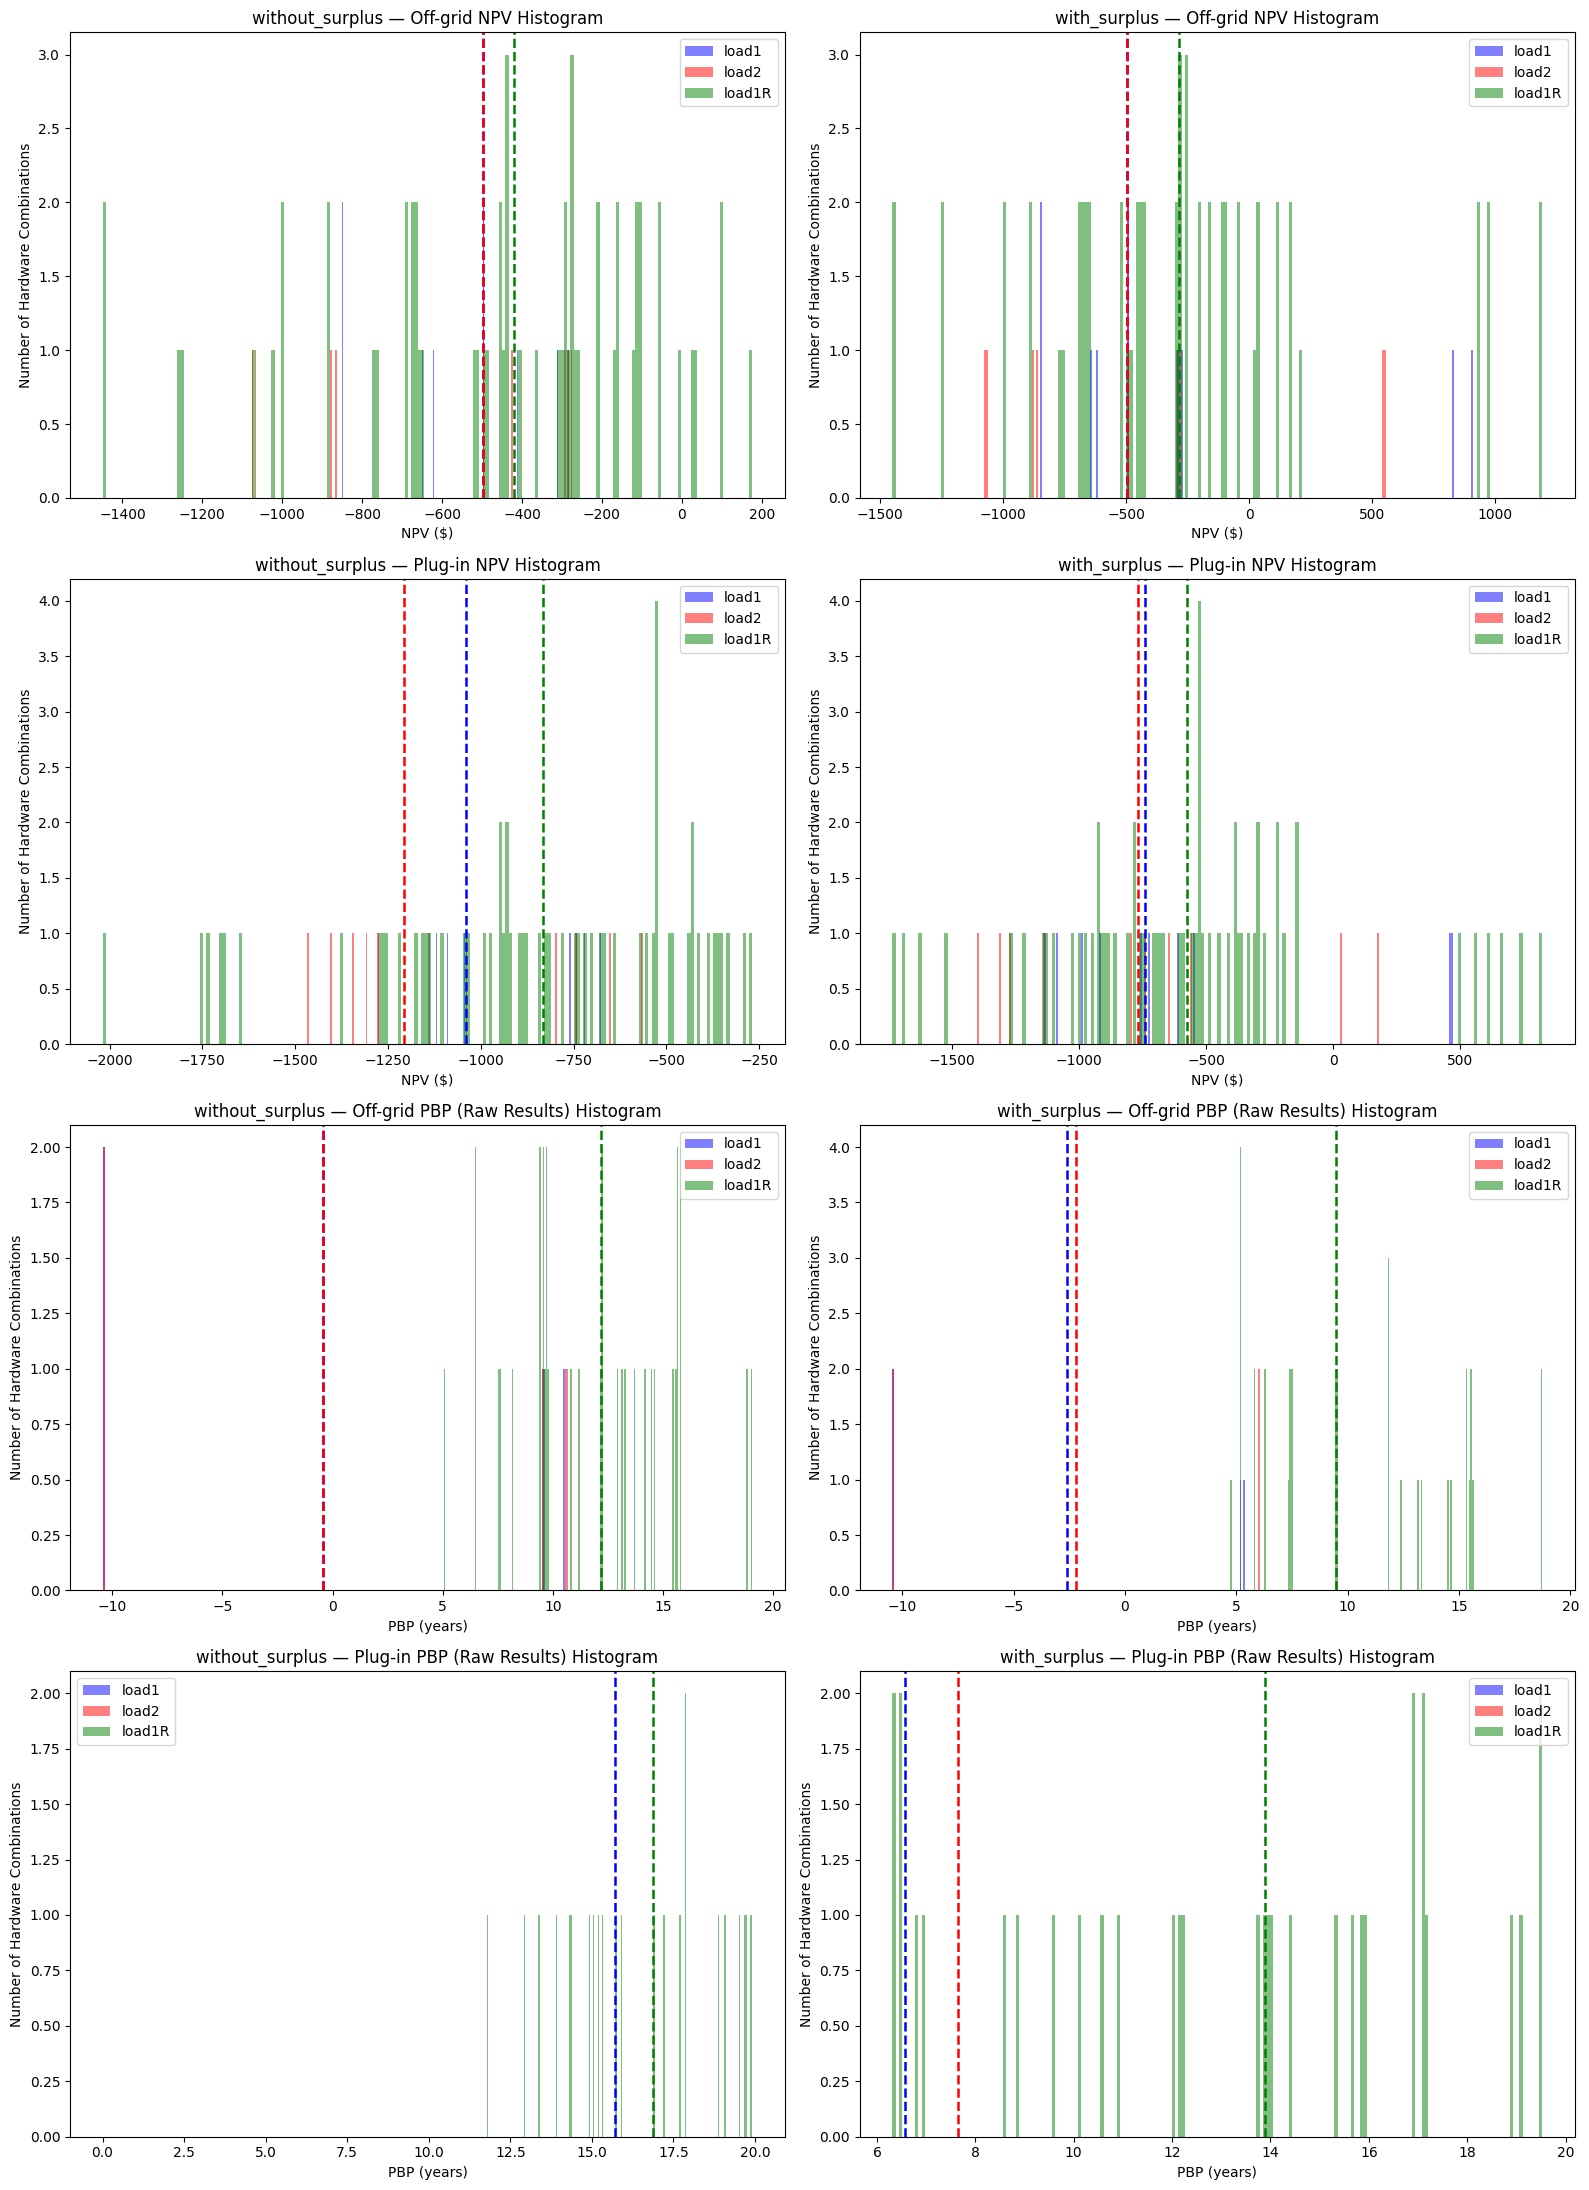

In [138]:
# Combined Results: PBP & NPV histograms (Off-grid & Plug-in, without/with surplus)
# Replaces the 8 separate plot blocks below with a single 4x2 subplot figure.
loads_colors = [('load1', 'blue'), ('load2', 'red'), ('load1R', 'green')]
scenarios = ['without_surplus', 'with_surplus']
plot_configs = [
    {
        'label': 'Off-grid NPV',
        'df': OGresultsNPV,
        'metric': 'NPV',
        'filter': None,#lambda df, col: df[col] < 20000,
        'xlabel': 'NPV ($)',
    },
    {
        'label': 'Plug-in NPV',
        'df': PIresultsNPV,
        'metric': 'NPV',
        'filter': None,
        'xlabel': 'NPV ($)',
    },
    {
        'label': 'Off-grid PBP (Raw Results)',
        'df': OGresultsPBP,
        'metric': 'PBP',
        'filter': lambda df, col: (df[col] > -20) & (df[col] < 20),
        'xlabel': 'PBP (years)',
    },
    {
        'label': 'Plug-in PBP (Raw Results)',
        'df': PIresultsPBP,
        'metric': 'PBP',
        'filter': lambda df, col: (df[col] > -20) & (df[col] < 20),
        'xlabel': 'PBP (years)',
    },
]
fig, axs = plt.subplots(len(plot_configs), len(scenarios), figsize=(16, 22))
for row, cfg in enumerate(plot_configs):
    df = cfg['df']
    for col_i, sc in enumerate(scenarios):
        ax = axs[row, col_i]
        for load_name, color in loads_colors:
            colname = f'{load_name}_{cfg["metric"]}_{sc}'
            if cfg['filter'] is not None:
                data = df[cfg['filter'](df, colname)][colname]
            else:
                data = df[colname]
            ax.hist(data, bins=200, facecolor=color, alpha=0.5, label=load_name)

            # Median line for this load, same color, dashed
            if len(data) > 0:
                med = data.median()
                ax.axvline(med, color=color, linestyle='--', linewidth=1.8)
        ax.set_title(f"{sc} — {cfg['label']} Histogram")
        ax.set_xlabel(cfg['xlabel'])
        ax.set_ylabel('Number of Hardware Combinations')
        ax.legend()
plt.tight_layout()
# Timestamped filename so repeated runs never overwrite a previous figure
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
plt.savefig(f'results/plots/PBP_NPV_combined_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()

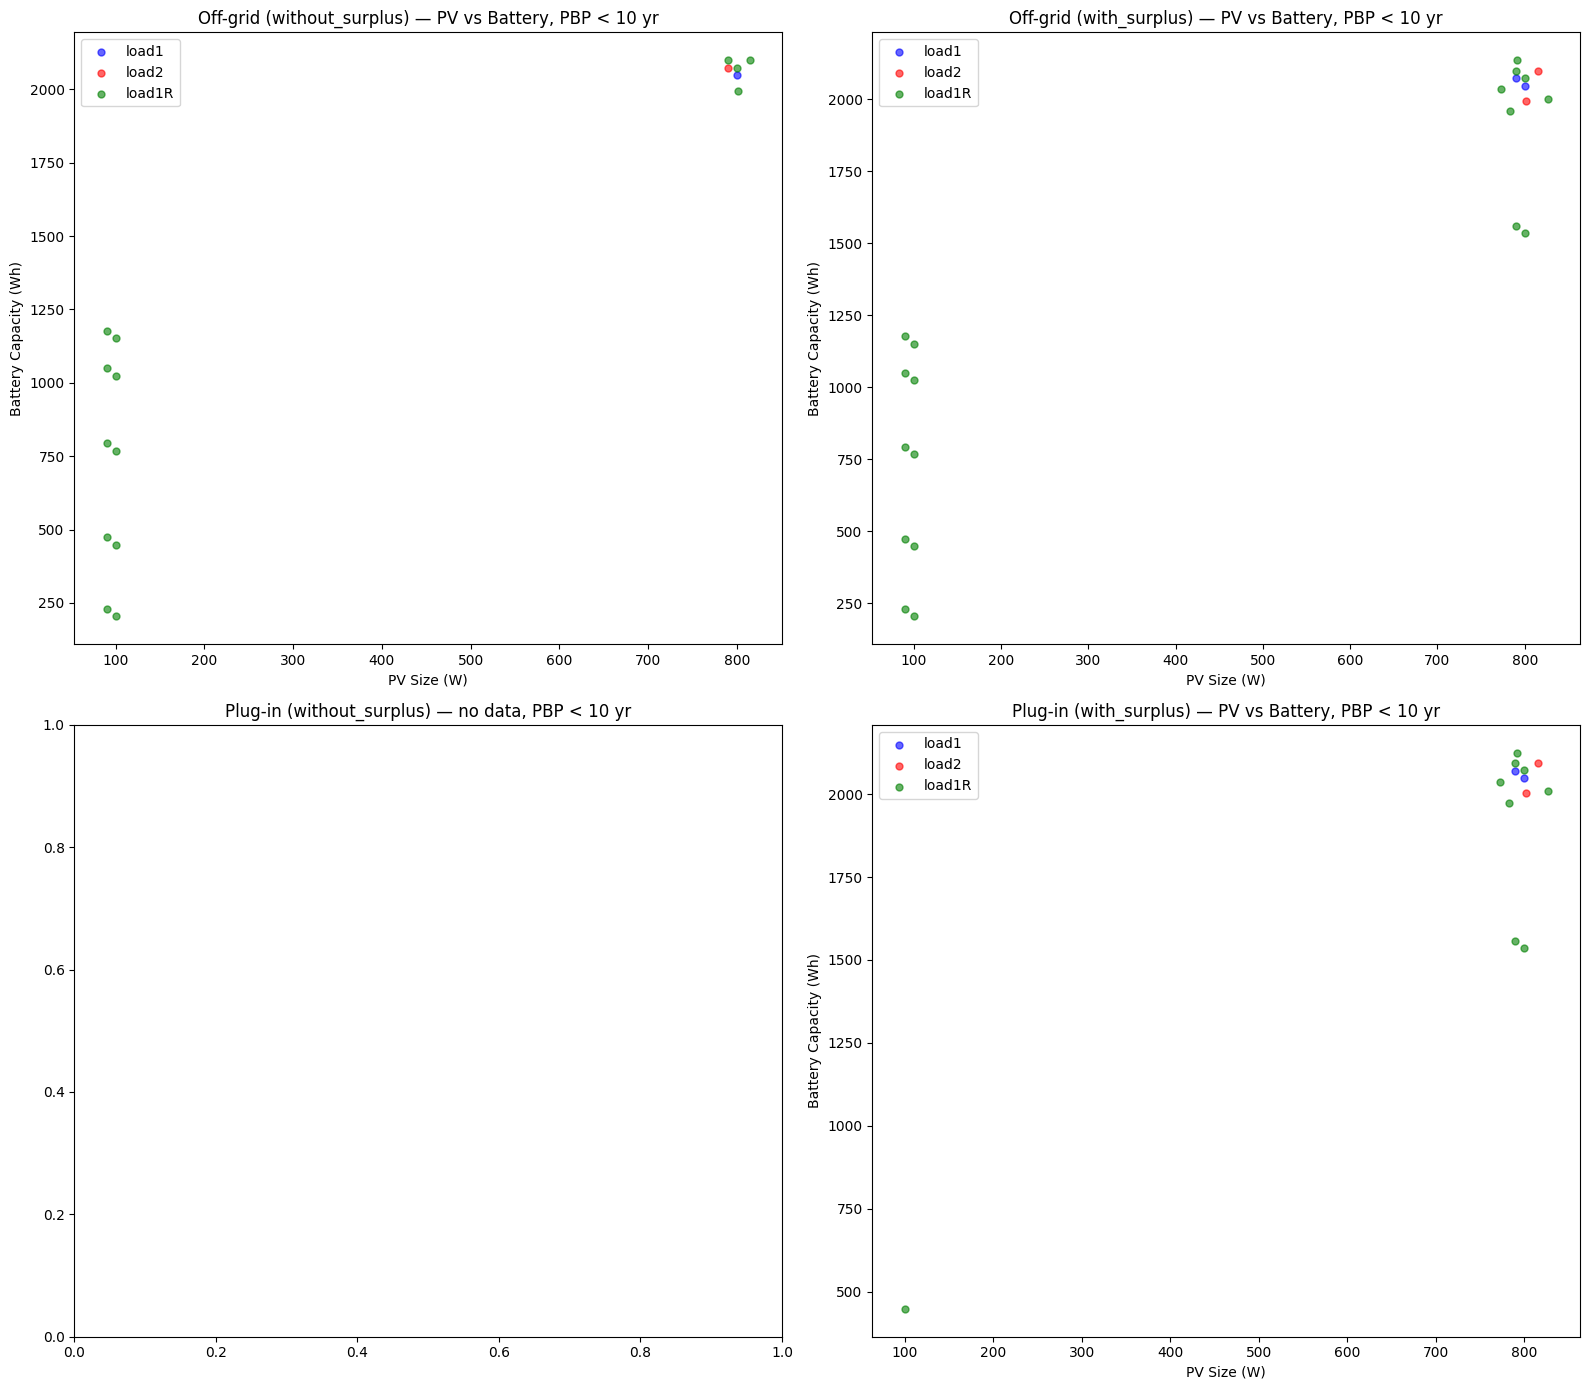

In [142]:
# pvW vs batWh scatter for hardware combos with PBP < 10 years
# 4 combos: Off-grid / Plug-in x without/with surplus
# Points sharing the exact same (pvW, batWh) - across ALL loads, not just within
# one load - are spread into a small spiral cluster so no dot hides another.

import numpy as np
from collections import defaultdict

loads_colors = [('load1', 'blue'), ('load2', 'red'), ('load1R', 'green')]

def jitter_shared_coords(coords, radius_frac=0.02):
    """coords: list of (x, y) tuples, possibly repeated.
    Returns parallel lists of jittered (x, y) where any points sharing the exact
    same original coordinate are spread into a golden-angle spiral, regardless
    of which series/load they came from."""
    if len(coords) == 0:
        return [], []

    xs = np.array([c[0] for c in coords], dtype=float)
    ys = np.array([c[1] for c in coords], dtype=float)
    x_range = (np.nanmax(xs) - np.nanmin(xs)) or 1.0
    y_range = (np.nanmax(ys) - np.nanmin(ys)) or 1.0

    groups = defaultdict(list)
    for i, coord in enumerate(coords):
        groups[coord].append(i)

    x_jit = xs.copy()
    y_jit = ys.copy()
    golden_angle = np.pi * (3 - np.sqrt(5))  # ~137.5 degrees, even spiral spacing

    for coord, idxs in groups.items():
        if len(idxs) == 1:
            continue
        for k, i in enumerate(idxs):
            angle = k * golden_angle
            r = radius_frac * np.sqrt(k)
            x_jit[i] = coord[0] + r * x_range * np.cos(angle)
            y_jit[i] = coord[1] + r * y_range * np.sin(angle)

    return x_jit, y_jit

combos = [
    ('Off-grid', og_results_df, 'without_surplus'),
    ('Off-grid', og_results_df, 'with_surplus'),
    ('Plug-in', pi_results_df, 'without_surplus'),
    ('Plug-in', pi_results_df, 'with_surplus'),
]

fig, axs = plt.subplots(2, 2, figsize=(16, 14))

for i, (label, df, sc) in enumerate(combos):
    ax = axs[i // 2, i % 2]

    # Collect (x, y, load_name) for ALL loads in this combo together, so the
    # dedup/jitter step sees duplicates across loads, not just within one load.
    all_coords = []
    all_loads = []
    for load_name, color in loads_colors:
        pbp_vals = df[f'{load_name}_PBP'].apply(
            lambda d: d.get(sc) if isinstance(d, dict) else None
        )
        mask = (pbp_vals >= 0) & (pbp_vals < 10)
        sub = df.loc[mask]
        for x, y in zip(sub['pvW'], sub['batWh']):
            all_coords.append((x, y))
            all_loads.append(load_name)

    if not all_coords:
        ax.set_title(f"{label} ({sc}) — no data, PBP < 10 yr")
        continue

    x_jit, y_jit = jitter_shared_coords(all_coords)

    # Split jittered points back out by load so each keeps its own color/legend entry
    for load_name, color in loads_colors:
        idxs = [k for k, ln in enumerate(all_loads) if ln == load_name]
        if not idxs:
            continue
        ax.scatter(
            [x_jit[k] for k in idxs],
            [y_jit[k] for k in idxs],
            facecolor=color, alpha=0.6, label=load_name, s=25
        )

    ax.set_title(f"{label} ({sc}) — PV vs Battery, PBP < 10 yr")
    ax.set_xlabel('PV Size (W)')
    ax.set_ylabel('Battery Capacity (Wh)')
    ax.legend()

plt.tight_layout()

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
plt.savefig(f'results/plots/pv_vs_bat_PBPunder10_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()

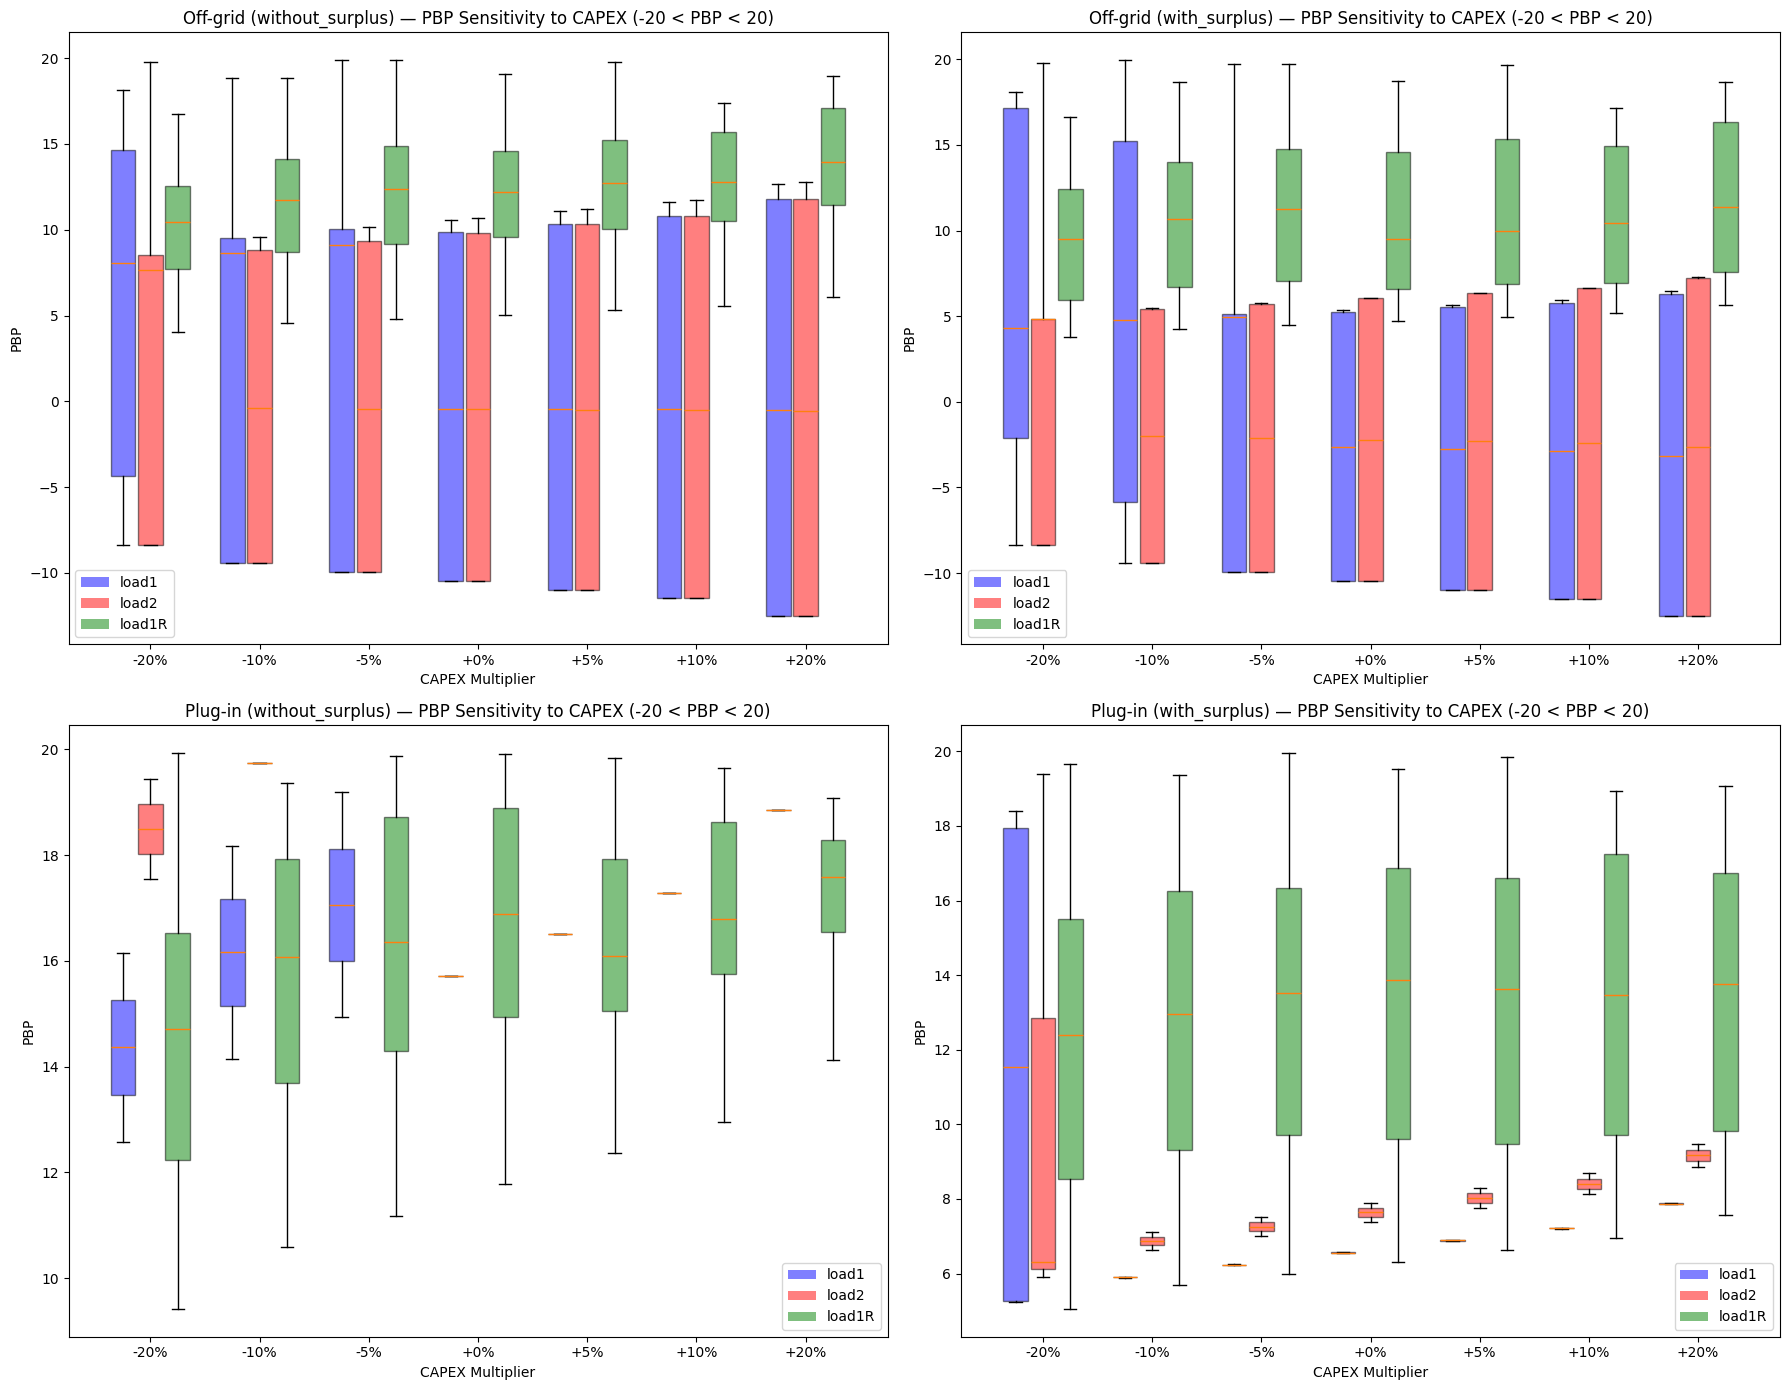

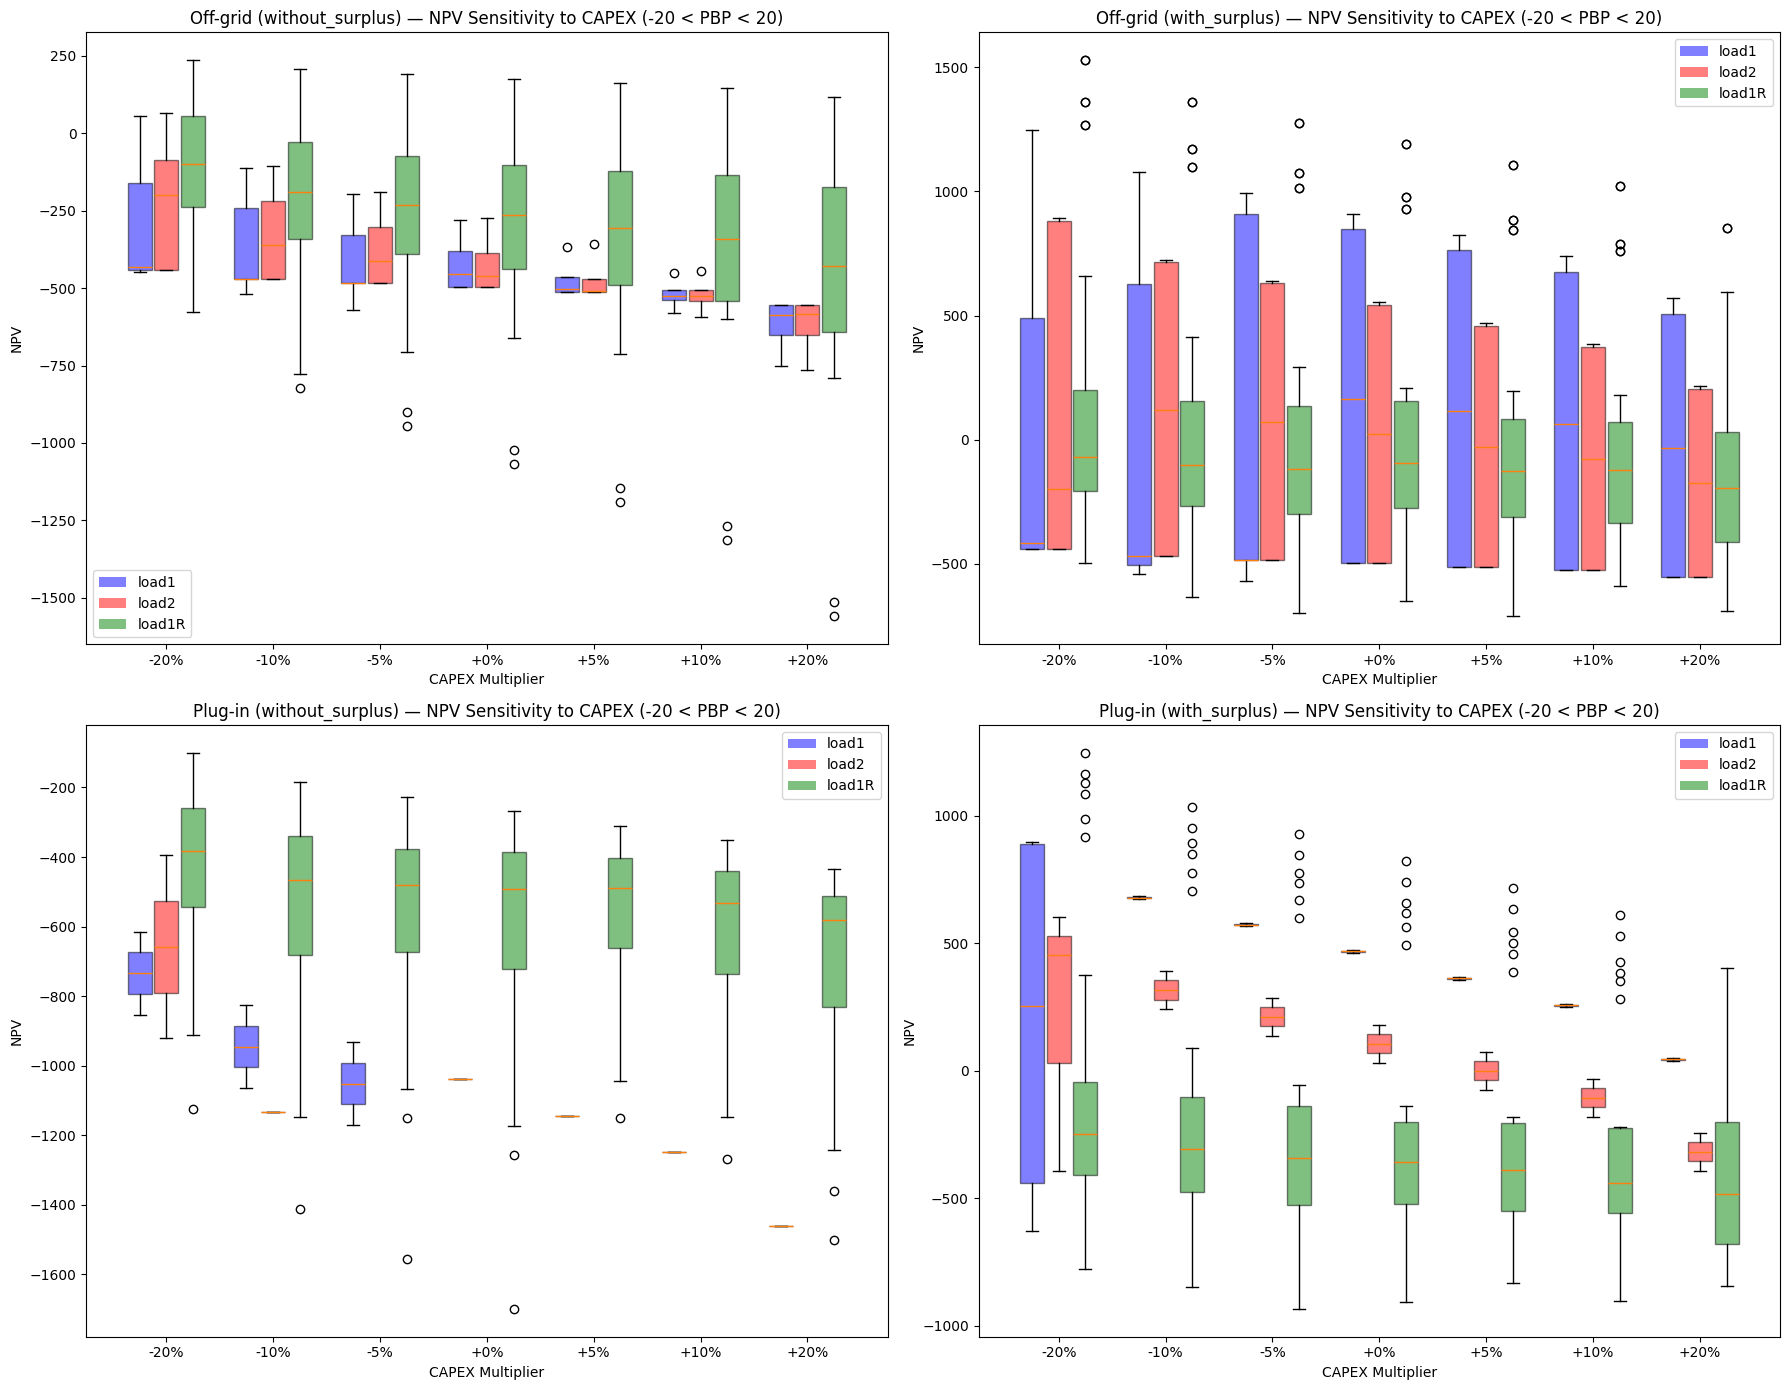

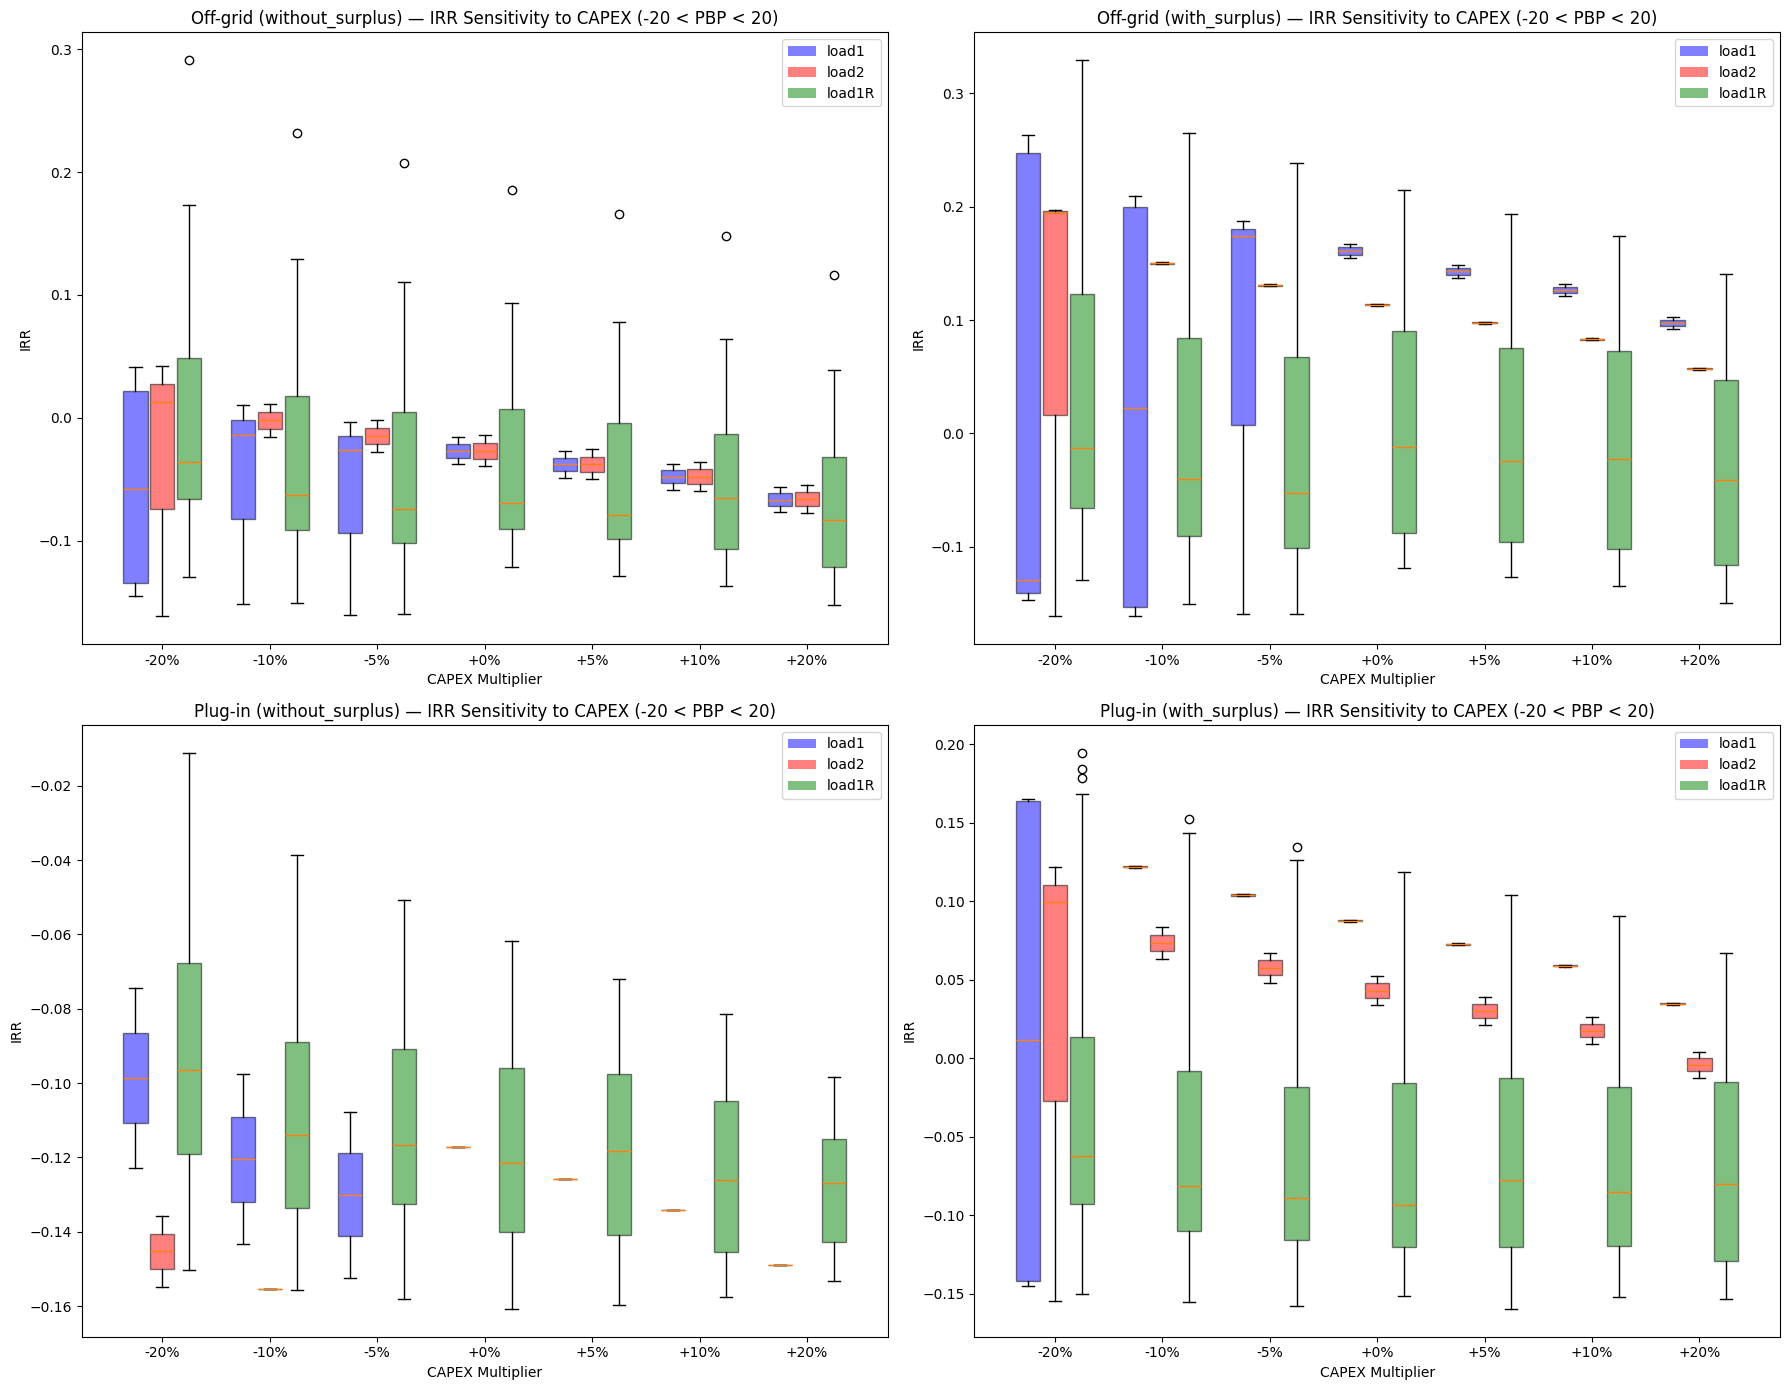

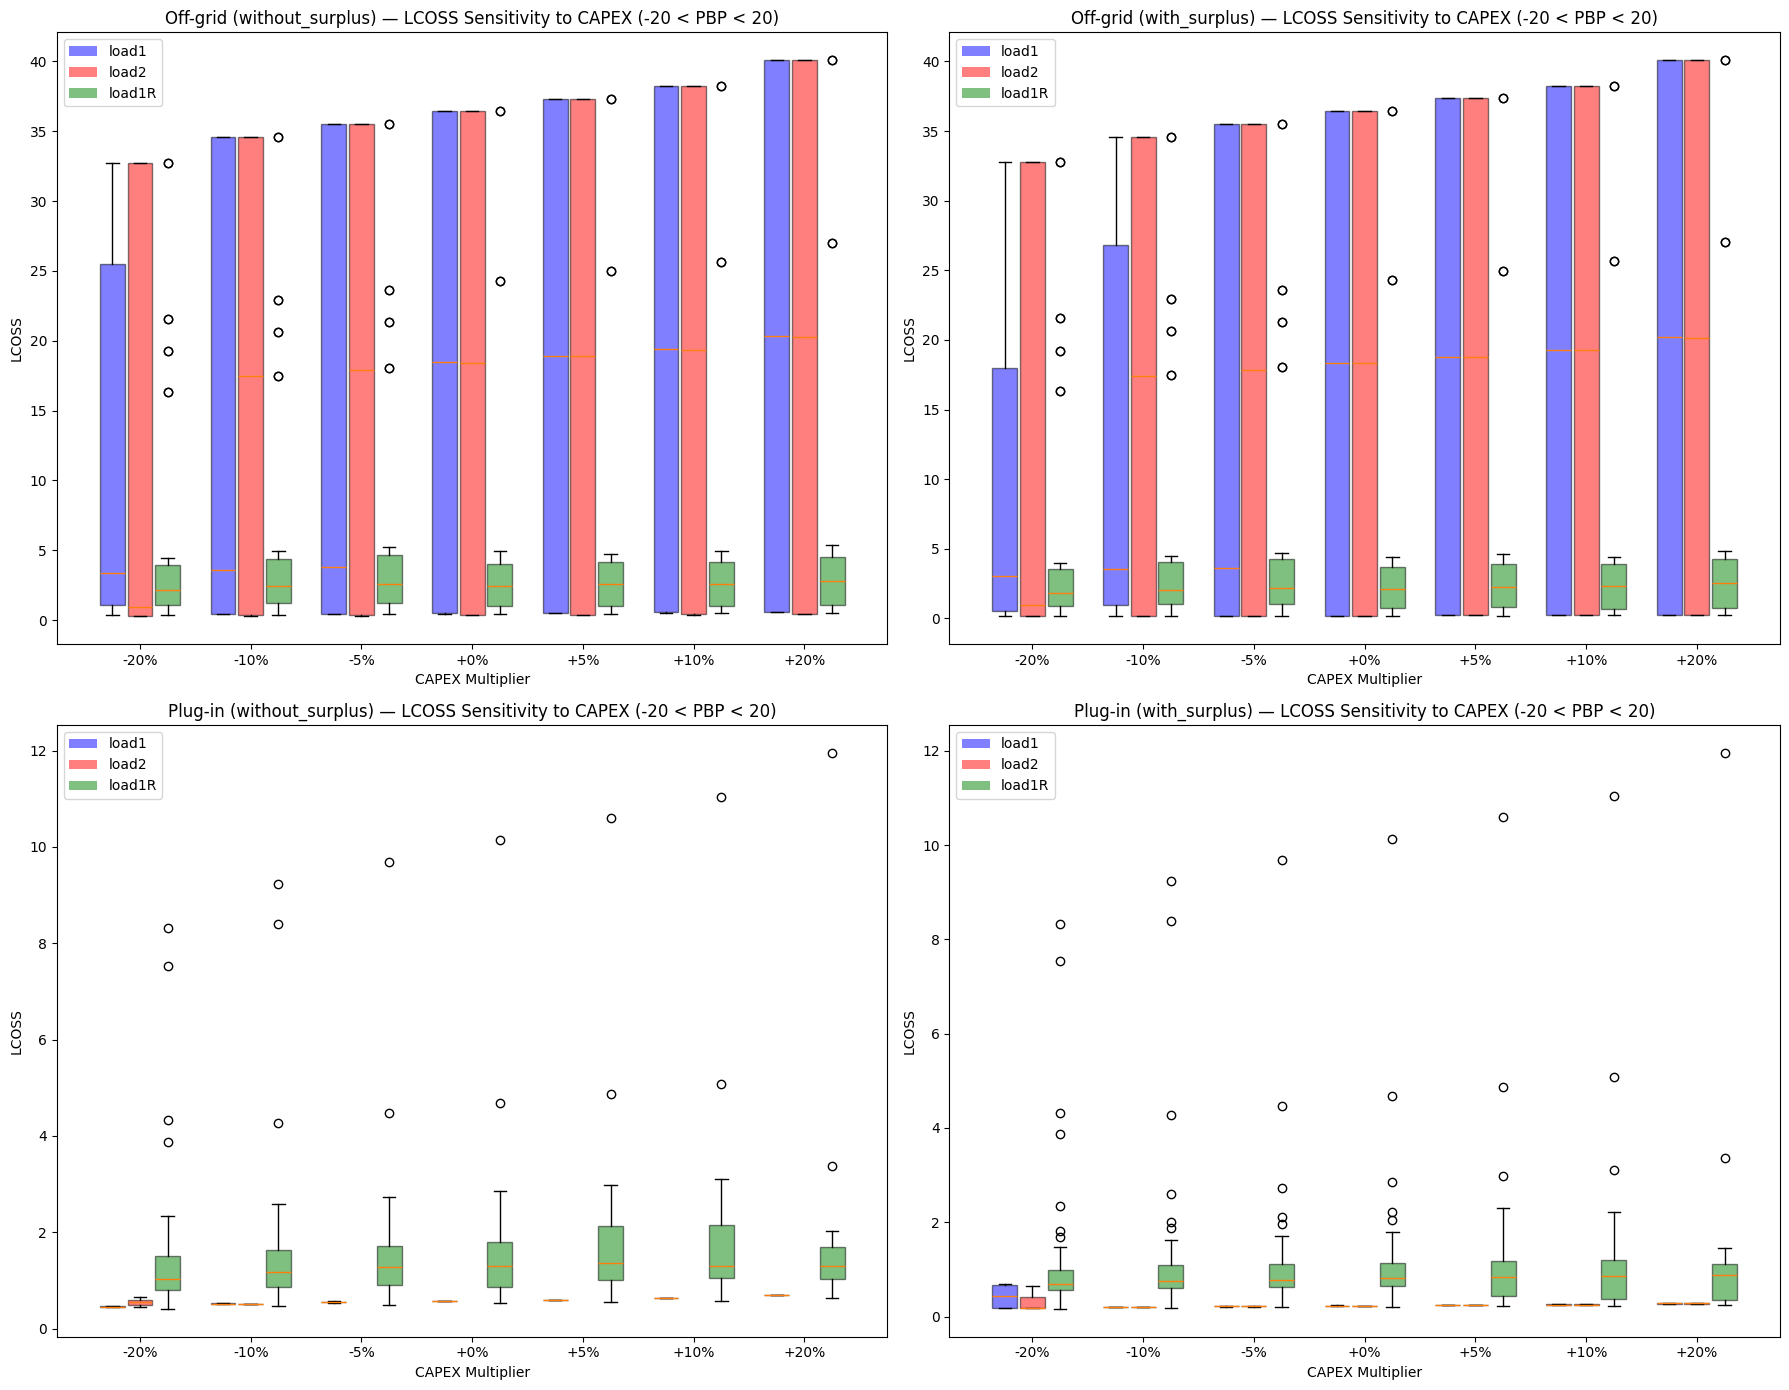

In [144]:
# CAPEX Sensitivity — box plots at each CAPEX multiplier level
# One figure per metric (PBP, NPV, IRR, LCOSS), each a 2x2 grid of
# Off-grid/Plug-in x without/with surplus combos.
# Filter: for each load/CAPEX-level/scenario, only include rows where that
# load's PBP at that same CAPEX level & scenario is between -20 and 20 years.
# This filter is applied consistently across all 4 metric figures.

capex_multipliers = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]  # must match main-loop values exactly
loads_colors = [('load1', 'blue'), ('load2', 'red'), ('load1R', 'green')]
metrics = ['PBP', 'NPV', 'IRR', 'LCOSS']

combos = [
    ('Off-grid', og_results_df, 'without_surplus'),
    ('Off-grid', og_results_df, 'with_surplus'),
    ('Plug-in', pi_results_df, 'without_surplus'),
    ('Plug-in', pi_results_df, 'with_surplus'),
]

width = 0.25  # horizontal spacing between the 3 grouped boxes at each CAPEX level

for metric in metrics:
    fig, axs = plt.subplots(2, 2, figsize=(18, 14))

    for i, (label, df, sc) in enumerate(combos):
        ax = axs[i // 2, i % 2]

        box_data = []
        positions = []
        colors_list = []

        for c_idx, capex in enumerate(capex_multipliers):
            for l_idx, (load_name, color) in enumerate(loads_colors):
                # PBP at this same load/capex/scenario, used purely as a filter
                pbp_col = f'{load_name}_PBP_capexSensitivity'
                pbp_vals = df[pbp_col].apply(
                    lambda d, cx=capex, s=sc: (
                        d.get(cx, {}).get(s) if isinstance(d, dict) else None
                    )
                )
                pbp_mask = pbp_vals.notna() & (pbp_vals > -20) & (pbp_vals < 20)

                # actual metric being plotted, filtered by the PBP mask above
                metric_col = f'{load_name}_{metric}_capexSensitivity'
                vals = df[metric_col].apply(
                    lambda d, cx=capex, s=sc: (
                        d.get(cx, {}).get(s) if isinstance(d, dict) else None
                    )
                )
                vals = vals[pbp_mask].dropna()

                if len(vals) == 0:
                    continue  # skip empty groups so boxplot doesn't choke on them

                pos = c_idx + (l_idx - 1) * width  # centered around c_idx, spread by load
                box_data.append(vals.values)
                positions.append(pos)
                colors_list.append(color)

        if not box_data:
            ax.set_title(f"{label} ({sc}) — {metric} — no data")
            continue

        bp = ax.boxplot(box_data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

        ax.set_xticks(range(len(capex_multipliers)))
        ax.set_xticklabels([f'{int(cm * 100):+d}%' for cm in capex_multipliers])
        ax.set_xlabel('CAPEX Multiplier')
        ax.set_ylabel(metric)
        ax.set_title(f'{label} ({sc}) — {metric} Sensitivity to CAPEX (-20 < PBP < 20)')

        # manual legend, since boxplot() doesn't label by group automatically
        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.5) for _, color in loads_colors]
        ax.legend(handles, [ln for ln, _ in loads_colors])

    plt.tight_layout()

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    plt.savefig(f'results/plots/capexSensitivity_{metric}_filtered_{timestamp}.png', dpi=150, bbox_inches='tight')
    plt.show()